# Dapur analisis storyboard — "Hujan Hari Ini, Wabah Bulan Depan"

**ASEAN Data Science Explorers 2026 · SDG 3 × 13 × 6 · tenggat storyboard 4 September 2026**

Notebook ini adalah *dapur* di balik storyboard: memverifikasi setiap angka yang diklaim
di `IDE-STORYBOARD.md`, memilih bentuk grafik, dan menyiapkan tabel turunan siap impor.
**Grafik final tetap wajib dibuat di SAP Analytics Cloud** (aturan lomba); grafik di sini
adalah purwarupa — tiap bagian menyertakan catatan *"Reproduksi di SAC"*.

Cara menjalankan ulang (dari akar proyek):

```bash
.venv/bin/jupyter lab analisis/analisis_storyboard.ipynb
```

| Bagian | Halaman storyboard | Keluaran |
|---|---|---|
| Beban dengue ASEAN | 2 (Masalah, 10%) | `g01` + `keluaran/dengue_asean_nasional_tahunan.csv` |
| Analisis 1: musiman | 5 | `g02` |
| Analisis 2: korelasi berjeda | 6 | `g03`, `g03b` + `keluaran/korelasi_jeda_nasional.csv` |
| Analisis 3: fase ENSO (kartu as) | 7 | `g04` |
| Analisis 4: peta panas provinsi×bulan | 8 | `g05_idn`, `g05_tha` |
| Analisis 5: lapisan kerentanan | 9 | `g06` |
| Sintesis: kalender risiko | 10 | `g07` + `keluaran/kalender_risiko_*.csv` |
| Ambang pemicu | 11–12 | `g08` + `keluaran/ambang_pemicu_evaluasi.csv` |
| Dampak: sensitivitas | 13 | angka jadi |
| Verifikasi klaim | 14 | tabel klaim vs hitungan |

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

# --- lokasi ---
DATA = Path("data/siap-sac") if Path("data/siap-sac").exists() else Path("../data/siap-sac")
GAMBAR = DATA.parent.parent / "analisis" / "gambar"
KELUARAN = DATA.parent.parent / "analisis" / "keluaran"
GAMBAR.mkdir(parents=True, exist_ok=True)
KELUARAN.mkdir(parents=True, exist_ok=True)

# --- palet (mengikuti palet tervalidasi: kategorikal urutan tetap, sekuensial 1 warna,
#     divergen biru<->merah dengan tengah netral; jangan diacak) ---
BIRU, ORANYE, AQUA, KUNING = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, SEK, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SURF, BASELINE = "#fcfcfb", "#c3c2b7"
RAMP_BIRU = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
CMAP_SEQ = LinearSegmentedColormap.from_list("biru", RAMP_BIRU)
CMAP_DIV = LinearSegmentedColormap.from_list(
    "divergen", ["#0d366b", "#2a78d6", "#9ec5f4", "#f0efec", "#f0a5a4", "#e34948", "#8f1f1f"]
)
FASE_URUT = ["La Nina kuat", "La Nina", "Netral", "El Nino", "El Nino kuat"]
FASE_WARNA = {"La Nina kuat": "#184f95", "La Nina": "#86b6ef", "Netral": "#b5b3ac",
              "El Nino": "#f0a5a4", "El Nino kuat": "#c53232"}
NAMA_BULAN = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun", "Jul", "Agu", "Sep", "Okt", "Nov", "Des"]

mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "text.color": INK, "axes.labelcolor": SEK, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": BASELINE, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

def simpan(fig, nama):
    fig.savefig(GAMBAR / f"{nama}.png")
    print(f"gambar tersimpan -> {GAMBAR / (nama + '.png')}")

# --- muat data ---
d = pd.read_csv(DATA / "dengue_iklim_bulanan.csv")
da = pd.read_csv(DATA / "dengue_asean.csv", low_memory=False)
ik = pd.read_csv(DATA / "iklim_bulanan_asean.csv")
oni = pd.read_csv(DATA / "enso_oni_bulanan.csv")
wash_rt = pd.read_csv(DATA / "wash_rumahtangga_asean.csv")
banjir = pd.read_csv(DATA / "kota_asean_paparan_banjir.csv")

for nama, df in [("dengue_iklim_bulanan", d), ("dengue_asean", da), ("iklim", ik),
                 ("oni", oni), ("wash_rt", wash_rt), ("banjir", banjir)]:
    print(f"{nama:22s} {len(df):>7,} baris".replace(",", "."))

dengue_iklim_bulanan    55.329 baris
dengue_asean            70.397 baris
iklim                    9.000 baris
oni                        918 baris
wash_rt                  8.692 baris
banjir                  30.348 baris


## Halaman 2 — Masalah: beban dengue ASEAN

⚠️ **Jebakan penjumlahan.** `dengue_asean.csv` memuat baris pada beberapa resolusi
sekaligus (Admin0/1/2 × Tahun/Bulan/Minggu). Ada **147 negara-tahun** yang tampil di
lebih dari satu resolusi — dijumlah mentah berarti dobel hitung. Sel berikut memilih
**satu kombinasi resolusi per negara-tahun** (prioritas: Admin0-Tahun → Admin1-Tahun →
Admin0-Bulan → Admin0-Minggu → Admin1-Bulan → Admin2-Bulan, hanya yang cakupan
waktunya lengkap) dan menyimpan hasil bersihnya ke
`keluaran/dengue_asean_nasional_tahunan.csv`.

🔧 **Reproduksi di SAC:** impor CSV keluaran ini (bukan `dengue_asean.csv` mentah) untuk
grafik nasional; garis total ASEAN + batang per negara tahun terbaru. Di SAC tidak ada
mekanisme dedup resolusi — lakukan di sini.

⚠️ **Soal "rekor 2023–24":** dalam data ini tahun rekor adalah **2019** (1,26 jt kasus,
9 negara). Total 2023 **tidak bisa dibandingkan** karena Vietnam & Filipina hanya lengkap
sampai 2022 — di storyboard, klaim rekor 2023–24 harus disitasi dari WHO/literatur
(mis. Tian dkk. 2025), bukan dari agregat berkas ini.

In [2]:
PRIORITAS = {("Admin0", "Year"): 0, ("Admin1", "Year"): 1, ("Admin0", "Month"): 2,
             ("Admin0", "Week"): 3, ("Admin1", "Month"): 4, ("Admin1", "Week"): 5,
             ("Admin2", "Month"): 6, ("Admin2", "Year"): 7, ("Admin2", "Week"): 8}

def pilih_kombinasi(g):
    kombo = []
    for (rs, rw), gg in g.groupby(["resolusi_spasial", "resolusi_waktu"]):
        if rw == "Year":
            lengkap = True
        elif rw == "Month":
            lengkap = gg["tanggal_mulai"].str[:7].nunique() >= 12
        else:  # Week
            lengkap = gg["tanggal_mulai"].nunique() >= 50
        kombo.append({"rs": rs, "rw": rw, "total": int(gg["kasus"].sum()),
                      "lengkap": lengkap, "prio": PRIORITAS.get((rs, rw), 9)})
    k = pd.DataFrame(kombo)
    ada = k[k["lengkap"]]
    pil = ada.sort_values("prio").iloc[0] if len(ada) else k.sort_values("total", ascending=False).iloc[0]
    return pil

rek = []
for (neg, iso, thn), g in da.groupby(["negara", "iso3", "tahun"]):
    p = pilih_kombinasi(g)
    rek.append({"negara": neg, "iso3": iso, "tahun": thn, "kasus": p["total"],
                "sumber_resolusi": f"{p['rs']}-{p['rw']}", "lengkap": p["lengkap"]})
nas = pd.DataFrame(rek)
nas.to_csv(KELUARAN / "dengue_asean_nasional_tahunan.csv", index=False)

lengkap = nas[nas["lengkap"]]
per_tahun = lengkap[lengkap["tahun"].between(2000, 2024)].groupby("tahun").agg(
    kasus=("kasus", "sum"), n_negara=("negara", "nunique"))
tampil = per_tahun[per_tahun["n_negara"] >= 8]
print("Tahun 2000–2024 dengan >= 8 negara berdata lengkap:", list(tampil.index))
print("\n5 tahun tertinggi (total negara berdata lengkap):")
print(tampil.sort_values("kasus", ascending=False).head().to_string())

# tahun terbaru (<= 2023) yang lengkap per negara — untuk batang perbandingan
terbaru = (lengkap[lengkap["tahun"] <= 2023].sort_values("tahun").groupby("negara").last()
           .sort_values("kasus", ascending=False))
print("\nTahun terbaru berdata lengkap per negara:")
print(terbaru[["tahun", "kasus", "sumber_resolusi"]].to_string())

Tahun 2000–2024 dengan >= 8 negara berdata lengkap: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]

5 tahun tertinggi (total negara berdata lengkap):
         kasus  n_negara
tahun                   
2019   1261249         9
2022    928632         9
2015    579189        10
2016    549679        10
2020    542024         9

Tahun terbaru berdata lengkap per negara:
                   tahun   kasus sumber_resolusi
negara                                          
Vietnam             2022  367729     Admin0-Year
Filipina            2022  220020     Admin0-Week
Thailand            2023  159219    Admin0-Month
Malaysia            2023  123133     Admin1-Year
Indonesia           2023  114720    Admin1-Month
Kamboja             2023   36206     Admin0-Week
Laos                2023   32084     Admin0-Week
Myanmar             2023   16130     Admin0-Year
Singapura           2023   10243     Admin0-Week
B

gambar tersimpan -> ../analisis/gambar/g01_beban_asean.png


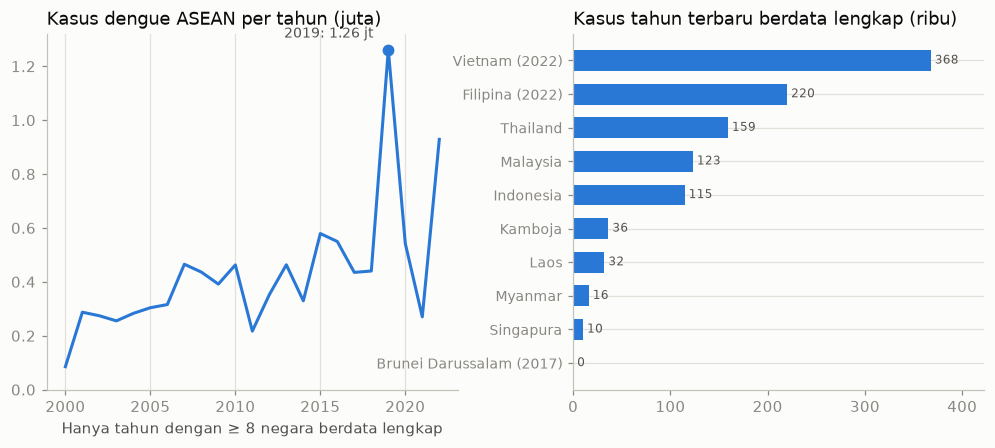

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"wspace": 0.28})

ax1.plot(tampil.index, tampil["kasus"] / 1e6, color=BIRU, lw=2)
puncak_thn = tampil["kasus"].idxmax()
ax1.scatter([puncak_thn], [tampil.loc[puncak_thn, "kasus"] / 1e6], color=BIRU, s=45, zorder=3)
ax1.annotate(f"{puncak_thn}: {tampil.loc[puncak_thn, 'kasus']/1e6:.2f} jt",
             (puncak_thn, tampil.loc[puncak_thn, "kasus"] / 1e6),
             textcoords="offset points", xytext=(-10, 8), ha="right", fontsize=9, color=SEK)
ax1.set_title("Kasus dengue ASEAN per tahun (juta)", loc="left")
ax1.set_xlabel("Hanya tahun dengan ≥ 8 negara berdata lengkap")
ax1.grid(axis="y")
ax1.set_ylim(bottom=0)

lab = [f"{n} ({int(r.tahun)})" if r.tahun != 2023 else n for n, r in terbaru.iterrows()]
y = np.arange(len(terbaru))
ax2.barh(y, terbaru["kasus"] / 1e3, color=BIRU, height=0.62)
ax2.set_yticks(y, lab, fontsize=9)
ax2.invert_yaxis()
for i, v in enumerate(terbaru["kasus"] / 1e3):
    ax2.text(v, i, f" {v:,.0f}".replace(",", "."), va="center", fontsize=8, color=SEK)
ax2.set_title("Kasus tahun terbaru berdata lengkap (ribu)", loc="left")
ax2.grid(axis="x")
ax2.margins(x=0.15)

simpan(fig, "g01_beban_asean")
plt.show()

## Halaman 5 — Analisis 1: musiman dengue vs hujan

Kurva rata-rata per bulan kalender (tahun-tahun lengkap, 2010+). Satu sumbu per panel —
kasus dan hujan **tidak** ditumpuk di sumbu ganda; di SAC pun buat dua grafik bertumpuk
dengan sumbu-X sama.

🔧 **Reproduksi di SAC:** dari `dengue_iklim_bulanan.csv`, chart batang `kasus` (SUM)
per `bulan`, filter negara; di bawahnya chart `hujan_jeda0` (AVG) per `bulan`.

IDN: 11 tahun lengkap (2010–2023)


THA: 13 tahun lengkap (2010–2022)
Empat bulan puncak Indonesia: ['Jan', 'Feb', 'Mar', 'Apr']
Indonesia: puncak hujan Des, puncak kasus Jan (hujan mendahului 1 bulan)
Thailand: puncak hujan Sep, puncak kasus Jul (musim beriringan — lihat korelasi jeda (hal. 6), bukan selisih puncak)


gambar tersimpan -> ../analisis/gambar/g02_musiman.png


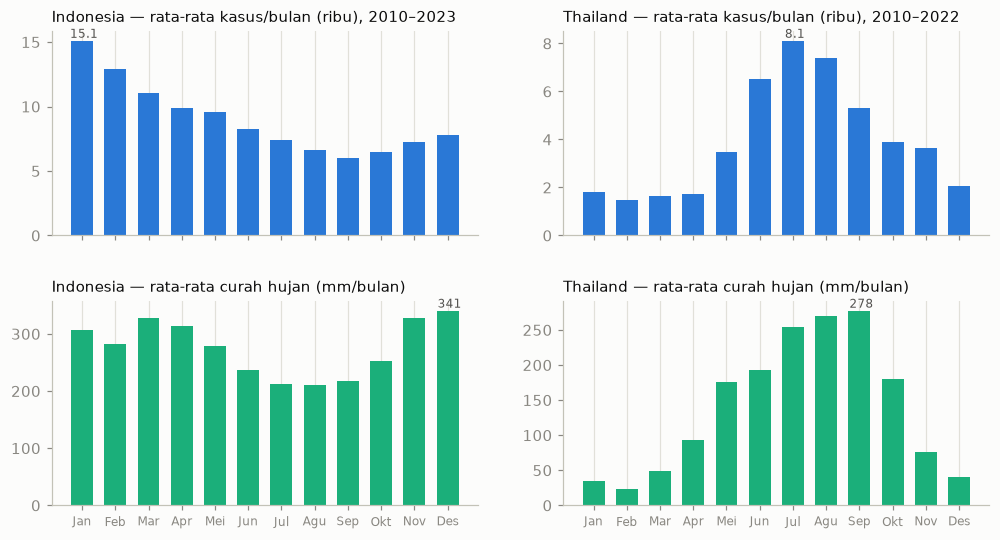

In [4]:
def seri_nasional(iso):
    '''Deret bulanan nasional: kasus (jumlah provinsi), suhu & hujan (rerata wilayah
    negara dari ERA5), ONI + fase. Diindeks Period bulanan tanpa lubang.'''
    kasus = d[d["iso3"] == iso].groupby("periode")["kasus"].sum().rename("kasus")
    iklim = ik[ik["iso3"] == iso].set_index("periode")[["suhu_c", "hujan_mm"]]
    ens = oni.set_index("periode")[["oni", "fase"]]
    s = pd.concat([kasus, iklim, ens], axis=1)
    s.index = pd.PeriodIndex(s.index, freq="M")
    s = s.sort_index()
    ada = s[s["kasus"].notna()].index
    s = s.reindex(pd.period_range(ada.min(), ada.max(), freq="M"))
    s["tahun"], s["bulan"] = s.index.year, s.index.month
    return s

def tahun_lengkap(s, mulai=2010):
    n = s[s["kasus"].notna() & (s["tahun"] >= mulai)].groupby("tahun")["bulan"].nunique()
    return sorted(n[n == 12].index)

musiman = {}
for iso in ["IDN", "THA"]:
    s = seri_nasional(iso)
    th = tahun_lengkap(s)
    v = s[s["tahun"].isin(th)]
    musiman[iso] = {"kasus": v.groupby("bulan")["kasus"].mean(),
                    "hujan": v.groupby("bulan")["hujan_mm"].mean(), "tahun": th}
    print(f"{iso}: {len(th)} tahun lengkap ({th[0]}–{th[-1]})")

PUNCAK_IDN = sorted(musiman["IDN"]["kasus"].nlargest(4).index)
print("Empat bulan puncak Indonesia:", [NAMA_BULAN[b - 1] for b in PUNCAK_IDN])

fig, axes = plt.subplots(2, 2, figsize=(11, 5.6), sharex="col", gridspec_kw={"hspace": 0.32})
for j, (iso, nama) in enumerate([("IDN", "Indonesia"), ("THA", "Thailand")]):
    m = musiman[iso]
    x = np.arange(1, 13)
    ax = axes[0, j]
    ax.bar(x, m["kasus"] / 1e3, color=BIRU, width=0.66)
    pb = m["kasus"].idxmax()
    ax.text(pb, m["kasus"].max() / 1e3, f" {m['kasus'].max()/1e3:.1f}", ha="center",
            va="bottom", fontsize=8, color=SEK)
    ax.set_title(f"{nama} — rata-rata kasus/bulan (ribu), {m['tahun'][0]}–{m['tahun'][-1]}",
                 loc="left", fontsize=10)
    ax.grid(axis="y")
    ax = axes[1, j]
    ax.bar(x, m["hujan"], color=AQUA, width=0.66)
    ph = m["hujan"].idxmax()
    ax.text(ph, m["hujan"].max(), f" {m['hujan'].max():.0f}", ha="center", va="bottom",
            fontsize=8, color=SEK)
    ax.set_title(f"{nama} — rata-rata curah hujan (mm/bulan)", loc="left", fontsize=10)
    ax.set_xticks(x, NAMA_BULAN, fontsize=8)
    ax.grid(axis="y")
    selisih = (pb - ph) % 12
    ket = (f"hujan mendahului {selisih} bulan" if 1 <= selisih <= 3 else
           "musim beriringan — lihat korelasi jeda (hal. 6), bukan selisih puncak")
    print(f"{nama}: puncak hujan {NAMA_BULAN[ph-1]}, puncak kasus {NAMA_BULAN[pb-1]} ({ket})")

simpan(fig, "g02_musiman")
plt.show()

## Halaman 6 — Analisis 2: korelasi berjeda (jendela 2010+)

Sapuan jeda 0–8 bulan untuk tiga prediktor (suhu, hujan, ONI) terhadap kasus bulanan
nasional. Warna divergen biru↔merah berpusat di nol. Sel ini juga **memverifikasi angka
yang diklaim di `IDE-STORYBOARD.md`**.

🔧 **Reproduksi di SAC:** tabel korelasi penuh tidak perlu dibuat di SAC — cukup satu
*scatter* (`suhu_jeda2` vs `kasus`) dan kutip tabel `keluaran/korelasi_jeda_nasional.csv`
di teks. Kolom jeda di `dengue_iklim_bulanan.csv` sudah dihitung (jeda 0–3 & ONI 0/3/4).

In [5]:
hasil = []
for iso in ["IDN", "THA"]:
    s = seri_nasional(iso)
    for pred, kol in [("Suhu", "suhu_c"), ("Hujan", "hujan_mm"), ("ONI", "oni")]:
        for jeda in range(9):
            # geser pada deret PENUH dulu, baru potong jendela 2010+ — kalau dibalik,
            # 4 bulan awal 2010 hilang (persis cara kolom *_jeda* di berkas dihitung)
            x, y = s[kol].shift(jeda), s["kasus"]
            m = (s.index >= "2010-01") & x.notna() & y.notna()
            hasil.append({"iso3": iso, "prediktor": pred, "jeda": jeda,
                          "r": y[m].corr(x[m]), "n_bulan": int(m.sum())})
kor = pd.DataFrame(hasil)
kor.to_csv(KELUARAN / "korelasi_jeda_nasional.csv", index=False)

KLAIM_KOR = [("IDN", "ONI", (3, 4), 0.59), ("IDN", "Suhu", (2, 3), 0.47),
             ("IDN", "Hujan", (1, 2), 0.40), ("THA", "Suhu", (2, 3), 0.57),
             ("THA", "Hujan", (0, 1), 0.48), ("THA", "ONI", (6, 7), 0.28)]
print("Verifikasi klaim IDE-STORYBOARD (r maksimum pada jeda yang diklaim):")
verif_kor = []
for iso, pred, jd, klaim in KLAIM_KOR:
    r = kor[(kor["iso3"] == iso) & (kor["prediktor"] == pred) & kor["jeda"].isin(jd)]["r"].max()
    cocok = abs(r - klaim) < 0.03
    verif_kor.append({"klaim": f"{iso} {pred} jeda {jd[0]}–{jd[1]}", "diklaim": klaim,
                      "terhitung": round(r, 2), "cocok": cocok})
    print(f"  {iso} {pred:6s} jeda {jd}: diklaim r={klaim:+.2f}, terhitung r={r:+.2f} "
          f"{'OK' if cocok else '<< PERIKSA'}")

Verifikasi klaim IDE-STORYBOARD (r maksimum pada jeda yang diklaim):
  IDN ONI    jeda (3, 4): diklaim r=+0.59, terhitung r=+0.59 OK
  IDN Suhu   jeda (2, 3): diklaim r=+0.47, terhitung r=+0.47 OK
  IDN Hujan  jeda (1, 2): diklaim r=+0.40, terhitung r=+0.40 OK
  THA Suhu   jeda (2, 3): diklaim r=+0.57, terhitung r=+0.57 OK
  THA Hujan  jeda (0, 1): diklaim r=+0.48, terhitung r=+0.48 OK
  THA ONI    jeda (6, 7): diklaim r=+0.28, terhitung r=+0.28 OK


gambar tersimpan -> ../analisis/gambar/g03_korelasi_jeda.png


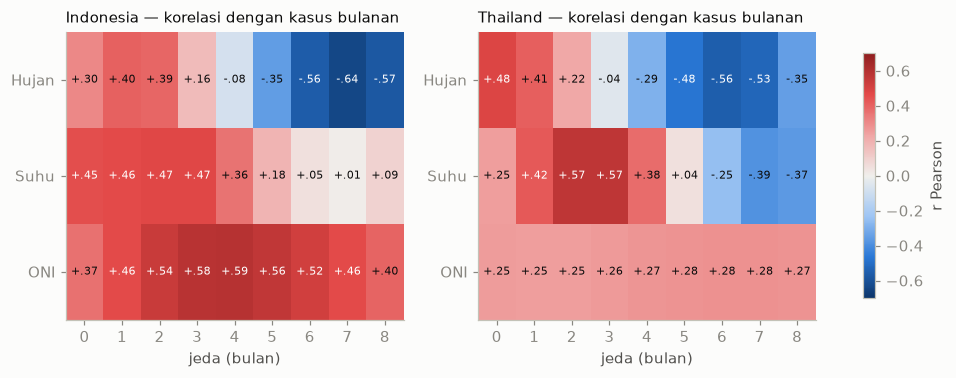

gambar tersimpan -> ../analisis/gambar/g03b_scatter_suhu.png


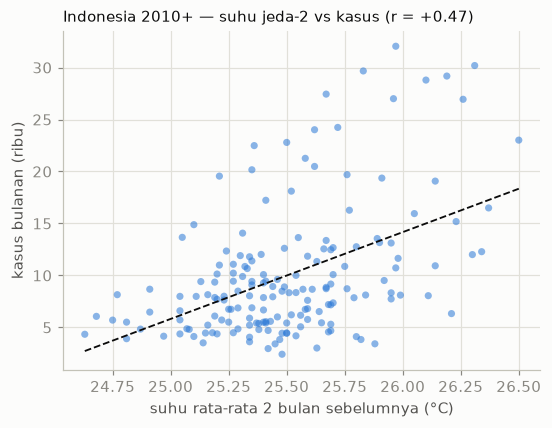

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"wspace": 0.22})
for ax, iso, nama in [(axes[0], "IDN", "Indonesia"), (axes[1], "THA", "Thailand")]:
    piv = kor[kor["iso3"] == iso].pivot(index="prediktor", columns="jeda", values="r") \
        .reindex(["Hujan", "Suhu", "ONI"])
    im = ax.imshow(piv, cmap=CMAP_DIV, vmin=-0.7, vmax=0.7, aspect="auto")
    ax.set_xticks(range(9), range(9))
    ax.set_yticks(range(3), piv.index)
    ax.set_xlabel("jeda (bulan)")
    ax.set_title(f"{nama} — korelasi dengan kasus bulanan", loc="left", fontsize=10)
    ax.grid(False)
    for i in range(piv.shape[0]):
        for jj in range(piv.shape[1]):
            v = piv.iloc[i, jj]
            ax.text(jj, i, f"{v:+.2f}".replace("+0.", "+.").replace("-0.", "-."),
                    ha="center", va="center", fontsize=7.5,
                    color="white" if abs(v) > 0.42 else INK)
fig.colorbar(im, ax=axes, shrink=0.85, label="r Pearson")
simpan(fig, "g03_korelasi_jeda")
plt.show()

# scatter purwarupa halaman 6: suhu jeda-2 vs kasus, Indonesia
s = seri_nasional("IDN")
x, y = s["suhu_c"].shift(2), s["kasus"] / 1e3
m = (s.index >= "2010-01") & x.notna() & y.notna()
fig, ax = plt.subplots(figsize=(5.6, 4))
ax.scatter(x[m], y[m], s=22, color=BIRU, alpha=0.55, edgecolors="none")
b, a = np.polyfit(x[m], y[m], 1)
xx = np.linspace(x[m].min(), x[m].max(), 20)
ax.plot(xx, a + b * xx, color=INK, lw=1.2, ls="--")
ax.set_xlabel("suhu rata-rata 2 bulan sebelumnya (°C)")
ax.set_ylabel("kasus bulanan (ribu)")
r = y[m].corr(x[m])
ax.set_title(f"Indonesia 2010+ — suhu jeda-2 vs kasus (r = {r:+.2f})", loc="left", fontsize=10)
simpan(fig, "g03b_scatter_suhu")
plt.show()

## Halaman 7 — Analisis 3 (kartu as): fase ENSO 4 bulan sebelumnya

Rata-rata kasus bulanan Indonesia menurut fase ENSO **4 bulan sebelumnya**. Panel kanan
menguji kekokohan: kontras El Niño bertahan di semua jeda 2–7 — sesuai pesan storyboard,
klaimnya adalah *"El Niño menaikkan risiko"*, **bukan** urutan monotonik kelima fase.

🔧 **Reproduksi di SAC:** batang `kasus` (AVG) per `fase_enso_jeda4` dari
`dengue_iklim_bulanan.csv` filter Indonesia — kolomnya sudah tersedia, tinggal seret.

In [7]:
s = seri_nasional("IDN")
for jeda in range(2, 8):          # geser pada deret penuh SEBELUM jendela dipotong
    s[f"fase_j{jeda}"] = s["fase"].shift(jeda)
s = s[s.index >= "2010-01"]

# cek konsistensi dengan kolom siap pakai di dengue_iklim_bulanan.csv
cek = d[d["iso3"] == "IDN"].groupby("periode")["fase_enso_jeda4"].first()
cek.index = pd.PeriodIndex(cek.index, freq="M")
cek = cek.reindex(s.index)
banding = s["fase_j4"].notna() & cek.notna()
sama = (s.loc[banding, "fase_j4"] == cek[banding]).mean()
print(f"Kecocokan fase turunan vs kolom fase_enso_jeda4 ({int(banding.sum())} bulan): {sama:.1%}")

v = s.dropna(subset=["kasus", "fase_j4"])
tab = v.groupby("fase_j4")["kasus"].agg(["mean", "count"]).reindex(FASE_URUT)
KLAIM_FASE = {"La Nina kuat": (7189, 3), "La Nina": (8111, 50), "Netral": (7597, 68),
              "El Nino": (12338, 35), "El Nino kuat": (21383, 16)}
print("\nRata-rata kasus/bulan menurut fase (klaim vs terhitung):")
verif_fase = []
for f in FASE_URUT:
    km, kn = KLAIM_FASE[f]
    tm, tn = tab.loc[f, "mean"], int(tab.loc[f, "count"])
    cocok = abs(tm - km) < km * 0.02 and tn == kn
    verif_fase.append({"klaim": f"fase {f}", "diklaim": km, "terhitung": round(tm),
                       "cocok": cocok})
    print(f"  {f:13s}: diklaim {km:>6,} (n={kn:2d}) | terhitung {tm:>8,.0f} (n={tn:2d}) "
          f"{'OK' if cocok else '<< PERIKSA'}")

# kekokohan lintas jeda
rob = []
for jeda in range(2, 8):
    fj = s[f"fase_j{jeda}"]
    vv = s[s["kasus"].notna() & fj.notna()]
    g = vv.groupby(f"fase_j{jeda}")["kasus"].mean()
    nino = vv[f"fase_j{jeda}"].isin(["El Nino", "El Nino kuat"])
    rob.append({"jeda": jeda, "kuat_vs_netral": g.get("El Nino kuat", np.nan) / g.get("Netral", np.nan),
                "elnino_vs_lainnya": vv[nino]["kasus"].mean() / vv[~nino]["kasus"].mean()})
rob = pd.DataFrame(rob).set_index("jeda")
print("\nKekokohan kontras El Nino lintas jeda:")
print(rob.round(2).to_string())

Kecocokan fase turunan vs kolom fase_enso_jeda4 (172 bulan): 100.0%

Rata-rata kasus/bulan menurut fase (klaim vs terhitung):
  La Nina kuat : diklaim  7,189 (n= 3) | terhitung    7,189 (n= 3) OK
  La Nina      : diklaim  8,111 (n=50) | terhitung    8,111 (n=50) OK
  Netral       : diklaim  7,597 (n=68) | terhitung    7,597 (n=68) OK
  El Nino      : diklaim 12,338 (n=35) | terhitung   12,338 (n=35) OK
  El Nino kuat : diklaim 21,383 (n=16) | terhitung   21,383 (n=16) OK

Kekokohan kontras El Nino lintas jeda:
      kuat_vs_netral  elnino_vs_lainnya
jeda                                   
2               2.66               2.05
3               2.90               2.05
4               2.81               1.95
5               2.43               1.74
6               2.13               1.59
7               1.76               1.48


gambar tersimpan -> ../analisis/gambar/g04_enso_fase.png


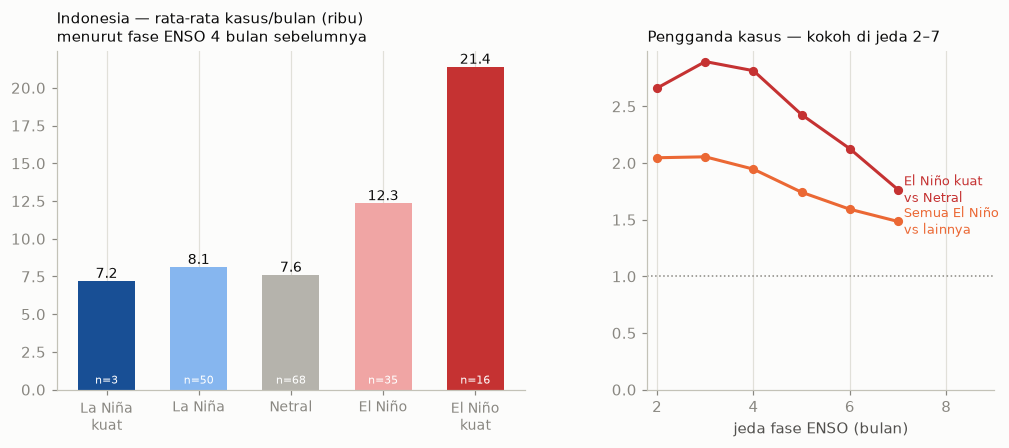

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"wspace": 0.3, "width_ratios": [1.35, 1]})

x = np.arange(len(FASE_URUT))
ax1.bar(x, tab["mean"] / 1e3, color=[FASE_WARNA[f] for f in FASE_URUT], width=0.62)
for i, f in enumerate(FASE_URUT):
    ax1.text(i, tab.loc[f, "mean"] / 1e3, f"{tab.loc[f,'mean']/1e3:.1f}", ha="center",
             va="bottom", fontsize=9, color=INK)
    ax1.text(i, 0.4, f"n={int(tab.loc[f,'count'])}", ha="center", fontsize=7.5, color="white")
ax1.set_xticks(x, ["La Niña\nkuat", "La Niña", "Netral", "El Niño", "El Niño\nkuat"], fontsize=9)
ax1.set_title("Indonesia — rata-rata kasus/bulan (ribu)\nmenurut fase ENSO 4 bulan sebelumnya", loc="left", fontsize=10)
ax1.grid(axis="y")

ax2.plot(rob.index, rob["kuat_vs_netral"], color="#c53232", lw=2, marker="o", ms=5)
ax2.plot(rob.index, rob["elnino_vs_lainnya"], color=ORANYE, lw=2, marker="o", ms=5)
ax2.text(rob.index[-1] + 0.12, rob["kuat_vs_netral"].iloc[-1], "El Niño kuat\nvs Netral",
         fontsize=8.5, color="#c53232", va="center")
ax2.text(rob.index[-1] + 0.12, rob["elnino_vs_lainnya"].iloc[-1], "Semua El Niño\nvs lainnya",
         fontsize=8.5, color=ORANYE, va="center")
ax2.axhline(1, color=MUTED, lw=1, ls=":")
ax2.set_xlabel("jeda fase ENSO (bulan)")
ax2.set_title("Pengganda kasus — kokoh di jeda 2–7", loc="left", fontsize=10)
ax2.set_xlim(1.8, 9)
ax2.set_ylim(bottom=0)
ax2.grid(axis="y")

simpan(fig, "g04_enso_fase")
plt.show()

## Halaman 8 — Analisis 4: peta panas provinsi × bulan

Nilai sel = **rata-rata persentase kasus tahunan yang jatuh di bulan itu** (hanya
tahun-tahun lengkap per provinsi, 2010+; tahun bertotal nol dilewati). Normalisasi per
provinsi ini penting: tanpa itu, Jawa Barat/Bangkok menenggelamkan provinsi kecil.
Baris diurutkan menurut bulan puncak → pola "gelombang" musiman terlihat.

🔧 **Reproduksi di SAC:** *heatmap* dengan baris `provinsi`, kolom `bulan`, ukuran =
`kasus` % of row total (Calculated Measure), filter tahun lengkap; atau impor
`keluaran/kalender_risiko_*.csv` yang sudah berisi share per bulan.

gambar tersimpan -> ../analisis/gambar/g05_heatmap_idn.png


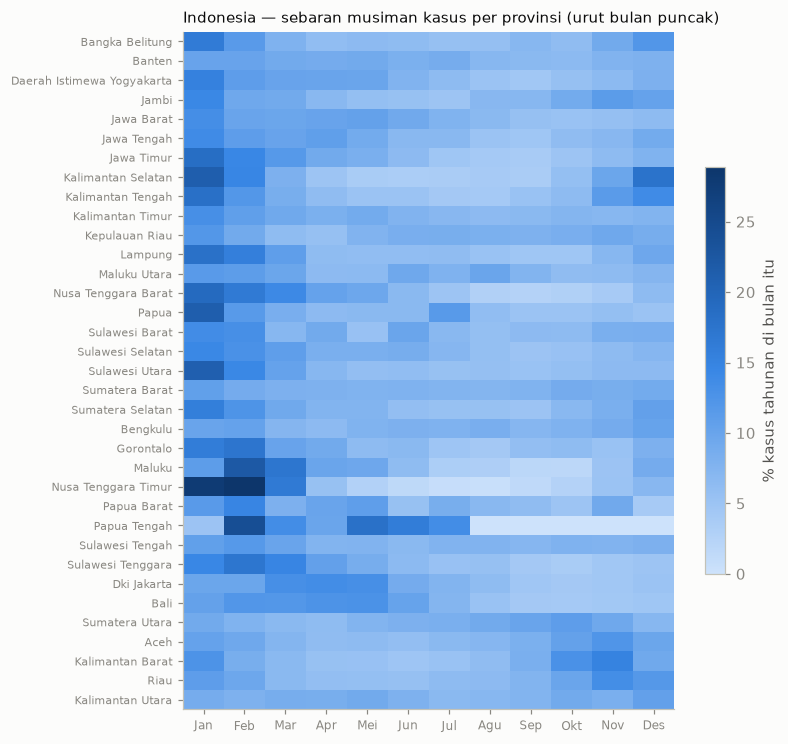

gambar tersimpan -> ../analisis/gambar/g05_heatmap_tha.png


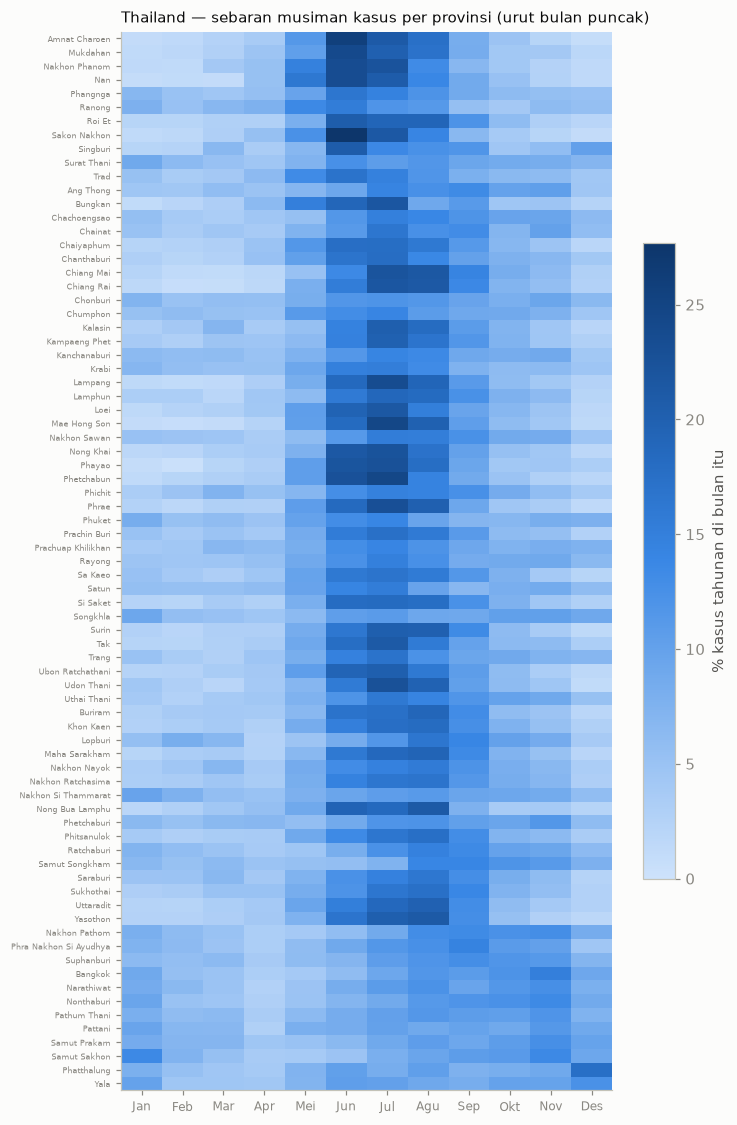

Indonesia: bulan puncak tersering -> {'Jan': np.int64(20), 'Feb': np.int64(8), 'Nov': np.int64(3)}
Thailand: bulan puncak tersering -> {'Jul': np.int64(38), 'Agu': np.int64(16), 'Jun': np.int64(11)}


In [9]:
def matriks_share(iso, mulai=2010):
    p = d[(d["iso3"] == iso) & (d["tahun"] >= mulai)].copy()
    n_bulan = p.groupby(["provinsi", "tahun"])["bulan"].transform("nunique")
    p = p[n_bulan == 12]
    p["tot_thn"] = p.groupby(["provinsi", "tahun"])["kasus"].transform("sum")
    p = p[p["tot_thn"] > 0]
    p["share"] = p["kasus"] / p["tot_thn"] * 100
    m = p.groupby(["provinsi", "bulan"])["share"].mean().unstack().reindex(columns=range(1, 13))
    return m.loc[m.idxmax(axis=1).sort_values(kind="stable").index]

def gambar_heatmap(m, judul, nama_berkas, tinggi, fs):
    fig, ax = plt.subplots(figsize=(7.2, tinggi))
    im = ax.imshow(m, cmap=CMAP_SEQ, vmin=0, vmax=min(30, np.nanmax(m.values)), aspect="auto")
    ax.set_xticks(range(12), NAMA_BULAN, fontsize=8)
    ax.set_yticks(range(len(m)), m.index.str.title(), fontsize=fs)
    ax.set_title(judul, loc="left", fontsize=10)
    ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.6, label="% kasus tahunan di bulan itu")
    simpan(fig, nama_berkas)
    plt.show()
    return m

m_idn = gambar_heatmap(matriks_share("IDN"),
    "Indonesia — sebaran musiman kasus per provinsi (urut bulan puncak)",
    "g05_heatmap_idn", 8.0, 7)
m_tha = gambar_heatmap(matriks_share("THA"),
    "Thailand — sebaran musiman kasus per provinsi (urut bulan puncak)",
    "g05_heatmap_tha", 12.5, 5)

for nama, m in [("Indonesia", m_idn), ("Thailand", m_tha)]:
    puncak = m.idxmax(axis=1).map(lambda b: NAMA_BULAN[b - 1]).value_counts()
    print(f"{nama}: bulan puncak tersering -> {dict(puncak.head(3))}")

## Halaman 9 — Analisis 5: lapisan kerentanan (SDG 6)

Tiga panel: akses air perpipaan rumah tangga, sanitasi dikelola aman, dan kota-kota
besar dengan porsi penduduk terbesar di zona banjir 100-tahunan. Menghubungkan cerita:
pasokan air tak andal → penampungan terbuka → nyamuk; genangan banjir → sarang jentik.

🔧 **Reproduksi di SAC:** batang dari `wash_rumahtangga_asean.csv` (filter layanan +
indikator + wilayah=Total, tahun terakhir) dan `kota_asean_paparan_banjir.csv`
(indikator persen, tahun 2020, filter kota besar).

gambar tersimpan -> ../analisis/gambar/g06_kerentanan.png


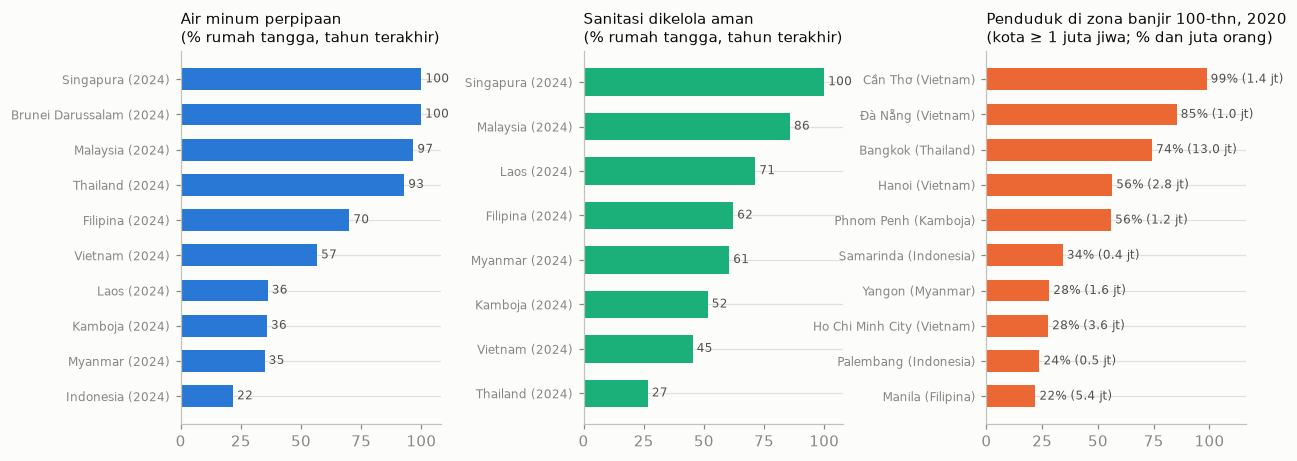

                   tahun  persen
negara                          
Malaysia            2024   96.69
Brunei Darussalam   2024   99.91
Singapura           2024  100.00


In [10]:
def wash_terbaru(layanan, indikator):
    w = wash_rt[(wash_rt["layanan"] == layanan) & (wash_rt["indikator"] == indikator) &
                (wash_rt["wilayah"] == "Total") & wash_rt["persen"].notna()]
    w = w.sort_values("tahun").groupby("negara").last()
    return w.sort_values("persen")

pipa = wash_terbaru("Air minum", "Perpipaan")
aman = wash_terbaru("Sanitasi", "Dikelola aman")

kb = banjir[(banjir["indikator"] == "Persen penduduk terpapar banjir 100 tahunan") &
            (banjir["tahun"] == 2020) & (banjir["penduduk_kota_2025"] >= 1e6)]
kb = kb.sort_values("nilai", ascending=False).head(10)
abs2020 = (banjir[(banjir["indikator"] == "Penduduk terpapar banjir 100 tahunan") &
                  (banjir["tahun"] == 2020)]
           .groupby(["negara", "kota"])["nilai"].max())

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.4), gridspec_kw={"wspace": 0.55})
for ax, tab, judul, warna in [
        (axes[0], pipa, "Air minum perpipaan\n(% rumah tangga, tahun terakhir)", BIRU),
        (axes[1], aman, "Sanitasi dikelola aman\n(% rumah tangga, tahun terakhir)", AQUA)]:
    y = np.arange(len(tab))
    ax.barh(y, tab["persen"], color=warna, height=0.62)
    ax.set_yticks(y, [f"{n} ({int(r.tahun)})" for n, r in tab.iterrows()], fontsize=8)
    for i, v in enumerate(tab["persen"]):
        ax.text(v, i, f" {v:.0f}", va="center", fontsize=8, color=SEK)
    ax.set_title(judul, loc="left", fontsize=10)
    ax.grid(axis="x")
    ax.set_xlim(0, 108)

y = np.arange(len(kb))
axes[2].barh(y, kb["nilai"], color=ORANYE, height=0.62)
axes[2].set_yticks(y, [f"{r.kota} ({r.negara})" for r in kb.itertuples()], fontsize=8)
for i, r in enumerate(kb.itertuples()):
    juta = abs2020.get((r.negara, r.kota), np.nan) / 1e6
    axes[2].text(r.nilai, i, f" {r.nilai:.0f}% ({juta:.1f} jt)", va="center", fontsize=8, color=SEK)
axes[2].invert_yaxis()
axes[2].set_title("Penduduk di zona banjir 100-thn, 2020\n(kota ≥ 1 juta jiwa; % dan juta orang)",
                  loc="left", fontsize=10)
axes[2].grid(axis="x")
axes[2].margins(x=0.18)

simpan(fig, "g06_kerentanan")
plt.show()
print(pipa.tail(3)[["tahun", "persen"]].to_string())

## Halaman 10 — Sintesis: kalender risiko

Dari matriks share musiman: **Puncak** = tiga bulan ber-share terbesar provinsi itu
(dan share ≥ 10%), **Siaga** = share ≥ 10% (≈ 1,2× rata bila merata), sisanya Normal.
Alarm iklim (halaman 11) tinggal digeser 1–3 bulan sebelum jendela Siaga provinsi.

🔧 **Reproduksi di SAC:** impor `keluaran/kalender_risiko_idn.csv` /
`_tha.csv` (format panjang), heatmap provinsi × bulan dengan ukuran `status_kode`
atau `share_persen`.

tabel tersimpan -> ../analisis/keluaran/kalender_risiko_idn.csv (420 baris)
tabel tersimpan -> ../analisis/keluaran/kalender_risiko_tha.csv (924 baris)


gambar tersimpan -> ../analisis/gambar/g07_kalender_risiko.png


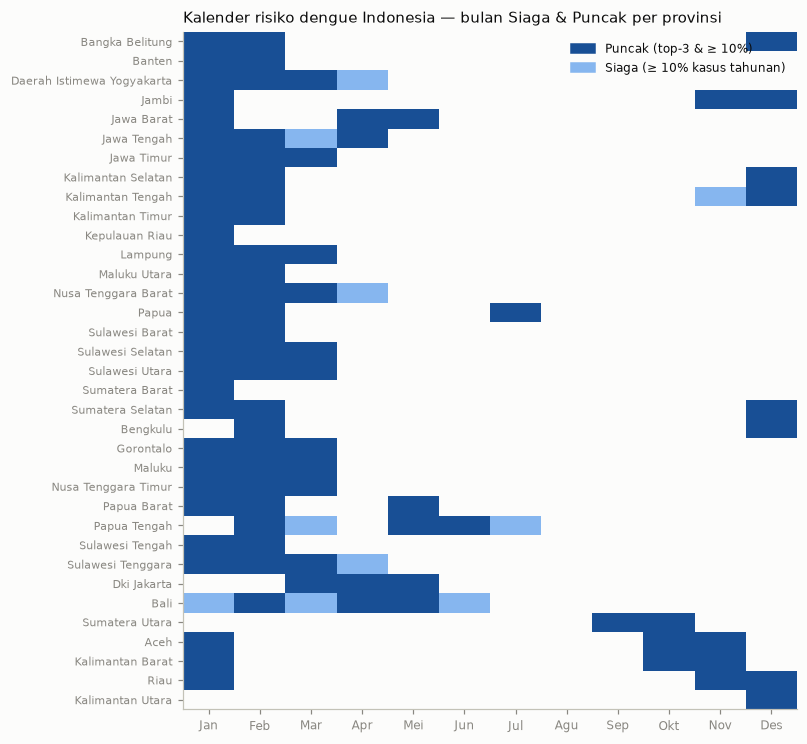


Bulan Siaga/Puncak tersering (Indonesia):
nama_bulan
Jan    30
Feb    25
Mar    14
Des     8
Apr     7
Nov     5


In [11]:
def kalender(m, negara, nama_berkas):
    rec = []
    for prov, baris in m.iterrows():
        top3 = set(baris.nlargest(3).index)
        for b in range(1, 13):
            sh = baris[b]
            status = ("Puncak" if (b in top3 and sh >= 10) else
                      "Siaga" if sh >= 10 else "Normal")
            rec.append({"negara": negara, "provinsi": prov.title(), "bulan": b,
                        "nama_bulan": NAMA_BULAN[b - 1], "share_persen": round(sh, 1),
                        "status": status, "status_kode": {"Normal": 0, "Siaga": 1, "Puncak": 2}[status]})
    k = pd.DataFrame(rec)
    k.to_csv(KELUARAN / f"{nama_berkas}.csv", index=False)
    print(f"tabel tersimpan -> {KELUARAN / (nama_berkas + '.csv')} ({len(k)} baris)")
    return k

kal_idn = kalender(m_idn, "Indonesia", "kalender_risiko_idn")
kal_tha = kalender(m_tha, "Thailand", "kalender_risiko_tha")

kode = kal_idn.pivot(index="provinsi", columns="bulan", values="status_kode") \
    .reindex([p.title() for p in m_idn.index])
fig, ax = plt.subplots(figsize=(7.2, 8))
ax.imshow(kode, cmap=ListedColormap([SURF, "#86b6ef", "#184f95"]), aspect="auto", vmin=0, vmax=2)
ax.set_xticks(range(12), NAMA_BULAN, fontsize=8)
ax.set_yticks(range(len(kode)), kode.index, fontsize=7)
ax.set_title("Kalender risiko dengue Indonesia — bulan Siaga & Puncak per provinsi",
             loc="left", fontsize=10)
ax.grid(False)
import matplotlib.patches as mpatches
ax.legend(handles=[mpatches.Patch(color="#184f95", label="Puncak (top-3 & ≥ 10%)"),
                   mpatches.Patch(color="#86b6ef", label="Siaga (≥ 10% kasus tahunan)")],
          loc="upper right", fontsize=8, frameon=False)
simpan(fig, "g07_kalender_risiko")
plt.show()

print("\nBulan Siaga/Puncak tersering (Indonesia):")
print(kal_idn[kal_idn["status"] != "Normal"]["nama_bulan"].value_counts().head(6).to_string())

## Halaman 11–12 — Ambang pemicu sederhana & viabilitas

Uji empat aturan alarm pada data Indonesia 2010+ (bulan **puncak** = kasus nasional di
kuartil teratas jendela itu). *Lift* = presisi ÷ laju dasar (25%); lift 2× berarti alarm
dua kali lebih tepat daripada menebak acak. Aturannya sengaja sederhana — bisa dijalankan
dinas kesehatan provinsi tanpa model apa pun, karena ONI **diramalkan berbulan-bulan ke
depan** oleh NOAA/BMKG.

Bulan puncak = kasus ≥ 11,932 (P75); laju dasar 25%

                         aturan  cakupan_alarm_%  sensitivitas_%  presisi_%  lift
     A. Musim (Jan/Feb/Mar/Apr)             33.7            67.4       50.0  2.00
   B. El Niño: ONI jeda-4 ≥ 0,5             29.7            67.4       56.9  2.27
          C. Musim ATAU El Niño             51.7            88.4       42.7  1.71
D. Musim DAN El Niño (eskalasi)             11.6            46.5      100.0  4.00
gambar tersimpan -> ../analisis/gambar/g08_alarm_enso.png


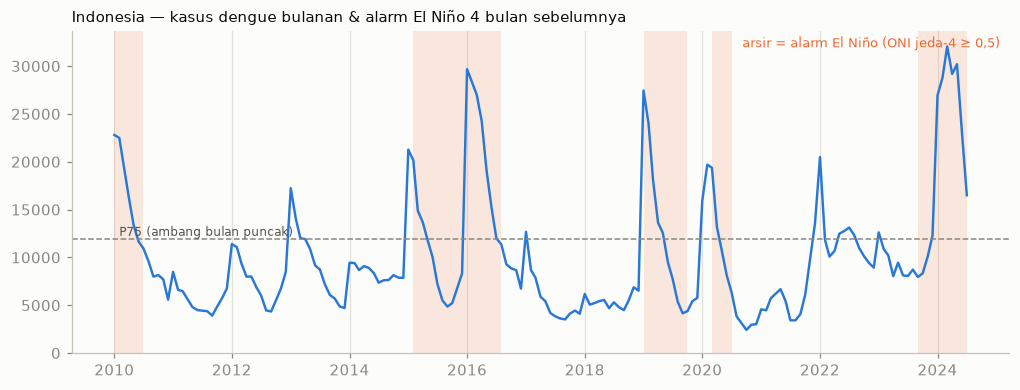

In [12]:
s = seri_nasional("IDN")
s["oni_j4"] = s["oni"].shift(4)      # geser dulu, baru potong jendela
s = s[s.index >= "2010-01"]
v = s.dropna(subset=["kasus", "oni_j4"]).copy()
p75 = v["kasus"].quantile(0.75)
v["puncak"] = v["kasus"] >= p75
bulan_v = pd.Series(v["bulan"].values, index=v.index)
nama_puncak = "/".join(NAMA_BULAN[b - 1] for b in PUNCAK_IDN)

aturan = {
    f"A. Musim ({nama_puncak})": bulan_v.isin(PUNCAK_IDN),
    "B. El Niño: ONI jeda-4 ≥ 0,5": v["oni_j4"] >= 0.5,
    "C. Musim ATAU El Niño": bulan_v.isin(PUNCAK_IDN) | (v["oni_j4"] >= 0.5),
    "D. Musim DAN El Niño (eskalasi)": bulan_v.isin(PUNCAK_IDN) & (v["oni_j4"] >= 0.5),
}
ev = []
for nama, alarm in aturan.items():
    ev.append({"aturan": nama,
               "cakupan_alarm_%": round(alarm.mean() * 100, 1),
               "sensitivitas_%": round((alarm & v["puncak"]).sum() / v["puncak"].sum() * 100, 1),
               "presisi_%": round((alarm & v["puncak"]).sum() / alarm.sum() * 100, 1),
               "lift": round(((alarm & v["puncak"]).sum() / alarm.sum()) / v["puncak"].mean(), 2)})
ev = pd.DataFrame(ev)
ev.to_csv(KELUARAN / "ambang_pemicu_evaluasi.csv", index=False)
print(f"Bulan puncak = kasus ≥ {p75:,.0f} (P75); laju dasar 25%\n")
print(ev.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 3.8))
t = v.index.to_timestamp()
alarm_b = (v["oni_j4"] >= 0.5).values
ax.fill_between(t, 0, v["kasus"].max() * 1.05, where=alarm_b, color=ORANYE, alpha=0.14,
                step="mid", lw=0)
ax.plot(t, v["kasus"], color=BIRU, lw=1.6)
ax.axhline(p75, color=MUTED, lw=1, ls="--")
ax.text(t[1], p75, "P75 (ambang bulan puncak)", fontsize=8, color=SEK, va="bottom")
ax.text(0.99, 0.95, "arsir = alarm El Niño (ONI jeda-4 ≥ 0,5)", transform=ax.transAxes,
        ha="right", fontsize=8.5, color=ORANYE)
ax.set_title("Indonesia — kasus dengue bulanan & alarm El Niño 4 bulan sebelumnya",
             loc="left", fontsize=10)
ax.set_ylim(0, v["kasus"].max() * 1.05)
ax.grid(axis="y")
simpan(fig, "g08_alarm_enso")
plt.show()

## Halaman 13 — Dampak: analisis sensitivitas

"Bila peringatan dini membuat X% kasus musim puncak tercegah, berapa kasus per tahun?"
— angka bahan halaman dampak, dihitung dari tahun-tahun lengkap terakhir.

In [13]:
s = seri_nasional("IDN")
th = [t for t in tahun_lengkap(s) if t >= 2015]
vv = s[s["tahun"].isin(th)]
per_tahun_idn = vv.groupby("tahun")["kasus"].sum()
rerata = per_tahun_idn.mean()
sh_puncak = vv[vv["bulan"].isin(PUNCAK_IDN)]["kasus"].sum() / vv["kasus"].sum()
print(f"Indonesia, tahun lengkap {th[0]}–{th[-1]} (n={len(th)}):")
print(f"  rata-rata kasus/tahun          : {rerata:,.0f}")
print(f"  porsi kasus di musim puncak ({'/'.join(NAMA_BULAN[b-1] for b in PUNCAK_IDN)}): {sh_puncak:.0%}")
for persen in (10, 20, 30):
    tercegah = rerata * sh_puncak * persen / 100
    print(f"  skenario {persen}% kasus musim puncak tercegah : ~{tercegah:,.0f} kasus/tahun")

Indonesia, tahun lengkap 2015–2023 (n=7):
  rata-rata kasus/tahun          : 104,753
  porsi kasus di musim puncak (Jan/Feb/Mar/Apr): 44%
  skenario 10% kasus musim puncak tercegah : ~4,656 kasus/tahun
  skenario 20% kasus musim puncak tercegah : ~9,312 kasus/tahun
  skenario 30% kasus musim puncak tercegah : ~13,968 kasus/tahun


---

# Analisis pendalaman — menutup celah pertanyaan juri

Lima uji tambahan, masing-masing menjawab satu keberatan yang hampir pasti muncul
di penjurian:

| Uji | Keberatan yang dijawab |
|---|---|
| Anomali (deseasonalisasi) | *"Korelasimu cuma pola musiman biasa."* |
| Konsistensi antar provinsi | *"Itu artefak agregat nasional."* |
| Uji luar-sampel | *"Aturanmu overfit ke data yang sama."* |
| Studi kasus episode El Niño | *"Berapa bulan tenggang nyatanya?"* |
| Peringkat insidens provinsi | *"Alarm ini untuk siapa dulu?"* |

## Pendalaman 1 — uji anomali: sinyal bertahan setelah musim dibuang

Semua nilai diubah jadi **z-score per bulan kalender** (anomali terhadap rata-rata
bulan itu sendiri): z Januari dihitung terhadap Januari-Januari lain, dst. Kalau
korelasi mentah hanya memantulkan siklus musiman, korelasi anomalinya akan runtuh
ke nol. ONI tidak di-z-kan — ONI memang sudah anomali (NOAA menghitungnya terhadap
klimatologi bergerak).

r mentah vs r ANOMALI pada jeda unggulan tiap prediktor:
  IDN ONI    jeda 3-4: +0.59 -> +0.56 (BERTAHAN)
  IDN Suhu   jeda 2-3: +0.47 -> +0.57 (BERTAHAN)
  IDN Hujan  jeda 1-2: +0.40 -> +0.24 (melemah — jujur laporkan)
  THA Suhu   jeda 2-3: +0.57 -> +0.44 (BERTAHAN)
  THA Hujan  jeda 0-1: +0.48 -> -0.11 (melemah — jujur laporkan)
  THA ONI    jeda 6-7: +0.28 -> +0.41 (BERTAHAN)


gambar tersimpan -> ../analisis/gambar/g09_korelasi_anomali.png


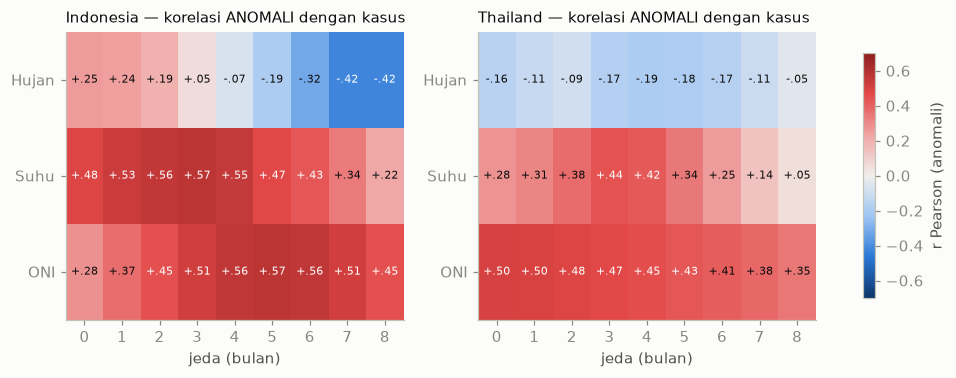

In [14]:
def anomali_z(w):
    z = pd.DataFrame(index=w.index)
    for kol in ["kasus", "suhu_c", "hujan_mm"]:
        rer = w.groupby("bulan")[kol].transform("mean")
        sd = w.groupby("bulan")[kol].transform("std")
        z[kol] = (w[kol] - rer) / sd
    z["oni"] = w["oni"]
    return z

hasil_anom = []
for iso in ["IDN", "THA"]:
    w = seri_nasional(iso)
    w = w[w.index >= "2010-01"]
    z = anomali_z(w)
    for pred, kol in [("Suhu", "suhu_c"), ("Hujan", "hujan_mm"), ("ONI", "oni")]:
        for jeda in range(9):
            x, y = z[kol].shift(jeda), z["kasus"]
            m = x.notna() & y.notna()
            hasil_anom.append({"iso3": iso, "prediktor": pred, "jeda": jeda,
                               "r": y[m].corr(x[m]), "n_bulan": int(m.sum())})
anom = pd.DataFrame(hasil_anom)
anom.to_csv(KELUARAN / "korelasi_jeda_anomali.csv", index=False)

print("r mentah vs r ANOMALI pada jeda unggulan tiap prediktor:")
BANDING_ANOM = []
for iso, pred, jd, _ in KLAIM_KOR:
    r_m = kor[(kor["iso3"] == iso) & (kor["prediktor"] == pred) & kor["jeda"].isin(jd)]["r"].max()
    r_a = anom[(anom["iso3"] == iso) & (anom["prediktor"] == pred) & anom["jeda"].isin(jd)]["r"].max()
    BANDING_ANOM.append({"iso3": iso, "prediktor": pred, "jeda": f"{jd[0]}-{jd[1]}",
                         "r_mentah": round(r_m, 2), "r_anomali": round(r_a, 2)})
    print(f"  {iso} {pred:6s} jeda {jd[0]}-{jd[1]}: {r_m:+.2f} -> {r_a:+.2f} "
          f"({'BERTAHAN' if r_a >= 0.3 else 'melemah — jujur laporkan'})")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"wspace": 0.22})
for ax, iso, nama in [(axes[0], "IDN", "Indonesia"), (axes[1], "THA", "Thailand")]:
    piv = anom[anom["iso3"] == iso].pivot(index="prediktor", columns="jeda", values="r") \
        .reindex(["Hujan", "Suhu", "ONI"])
    im = ax.imshow(piv, cmap=CMAP_DIV, vmin=-0.7, vmax=0.7, aspect="auto")
    ax.set_xticks(range(9), range(9))
    ax.set_yticks(range(3), piv.index)
    ax.set_xlabel("jeda (bulan)")
    ax.set_title(f"{nama} — korelasi ANOMALI dengan kasus", loc="left", fontsize=10)
    ax.grid(False)
    for i in range(3):
        for jj in range(9):
            v = piv.iloc[i, jj]
            ax.text(jj, i, f"{v:+.2f}".replace("+0.", "+.").replace("-0.", "-."),
                    ha="center", va="center", fontsize=7.5,
                    color="white" if abs(v) > 0.42 else INK)
fig.colorbar(im, ax=axes, shrink=0.85, label="r Pearson (anomali)")
simpan(fig, "g09_korelasi_anomali")
plt.show()

## Pendalaman 2 — konsistensi antar provinsi

Efek El Niño dihitung **per provinsi**: rasio rata-rata kasus bulan berfase El Niño
(jeda 4) terhadap bulan lainnya, jendela 2010+. Kalau efeknya nyata (bukan artefak
satu-dua provinsi raksasa yang mendominasi agregat), mayoritas provinsi harus punya
rasio > 1 — diuji formal dengan uji tanda binomial.

IDN: 33/34 provinsi rata-rata kasusnya lebih tinggi pada bulan berfase El Nino (jeda 4)   [uji tanda, p = 2e-09]
THA: 70/77 provinsi rata-rata kasusnya lebih tinggi pada bulan berfase El Nino (jeda 4)   [uji tanda, p = 1.8e-14]


gambar tersimpan -> ../analisis/gambar/g10_konsistensi_provinsi.png


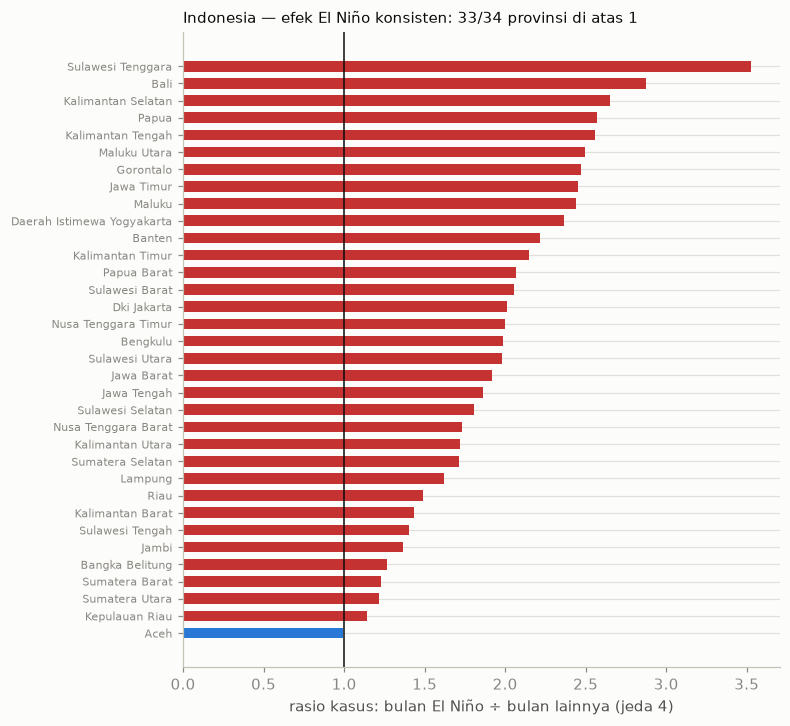

In [15]:
from scipy.stats import binomtest

kons = []
for iso in ["IDN", "THA"]:
    p = d[(d["iso3"] == iso) & (d["tahun"] >= 2010)].dropna(subset=["kasus", "fase_enso_jeda4"])
    for prov, g in p.groupby("provinsi"):
        nino = g["fase_enso_jeda4"].isin(["El Nino", "El Nino kuat"])
        if nino.sum() >= 12 and (~nino).sum() >= 24 and g.loc[~nino, "kasus"].mean() > 0:
            kons.append({"iso3": iso, "provinsi": prov,
                         "rasio": g.loc[nino, "kasus"].mean() / g.loc[~nino, "kasus"].mean(),
                         "n_bulan_nino": int(nino.sum())})
kons = pd.DataFrame(kons)

KONSIS = {}
for iso in ["IDN", "THA"]:
    k = kons[kons["iso3"] == iso]
    naik = int((k["rasio"] > 1).sum())
    p_val = binomtest(naik, len(k), 0.5, alternative="greater").pvalue
    KONSIS[iso] = (naik, len(k), p_val)
    print(f"{iso}: {naik}/{len(k)} provinsi rata-rata kasusnya lebih tinggi pada bulan "
          f"berfase El Nino (jeda 4)   [uji tanda, p = {p_val:.2g}]")

k = kons[kons["iso3"] == "IDN"].sort_values("rasio")
fig, ax = plt.subplots(figsize=(7, 7.5))
warna = ["#c53232" if r > 1 else "#2a78d6" for r in k["rasio"]]
ax.barh(np.arange(len(k)), k["rasio"], color=warna, height=0.62)
ax.axvline(1, color=INK, lw=1)
ax.set_yticks(np.arange(len(k)), k["provinsi"].str.title(), fontsize=7)
ax.set_xlabel("rasio kasus: bulan El Niño ÷ bulan lainnya (jeda 4)")
naik, tot, p_val = KONSIS["IDN"]
ax.set_title(f"Indonesia — efek El Niño konsisten: {naik}/{tot} provinsi di atas 1",
             loc="left", fontsize=10)
ax.grid(axis="x")
simpan(fig, "g10_konsistensi_provinsi")
plt.show()

## Pendalaman 3 — uji luar-sampel & replikasi Thailand

Aturan eskalasi diambil **hanya dari 2010–2016** (bulan puncak + ambang ONI 0,5 yang
memang standar NOAA), lalu diuji buta pada **2017–2024** yang tidak pernah dilihat.
"Bulan puncak" pada tiap segmen didefinisikan relatif (kuartil teratas segmen itu)
supaya tren pelaporan tidak mengacaukan perbandingan. Untuk Thailand — yang sinyal
ENSO-nya lemah — aturannya memakai prediktor terbaik mereka: **anomali suhu jeda-2**.

In [16]:
def metrik_aturan(seg, alarm):
    tgt = seg["kasus"] >= seg["kasus"].quantile(0.75)
    pres = (alarm & tgt).sum() / alarm.sum() if alarm.sum() else np.nan
    return {"n_bulan": len(seg), "cakupan_%": round(alarm.mean() * 100, 1),
            "sensitivitas_%": round((alarm & tgt).sum() / tgt.sum() * 100, 1),
            "presisi_%": round(pres * 100, 1), "lift": round(pres / tgt.mean(), 2)}

# --- Indonesia: musim puncak (dari 2010-2016 saja) DAN ONI jeda-4 >= 0,5 ---
s = seri_nasional("IDN")
s["oni_j4"] = s["oni"].shift(4)
w = s[s.index >= "2010-01"].dropna(subset=["kasus", "oni_j4"]).copy()
latih, uji = w[w.index <= "2016-12"], w[w.index >= "2017-01"]
puncak_latih = sorted(latih.groupby("bulan")["kasus"].mean().nlargest(4).index)
print("Bulan puncak versi data latih 2010-2016:", [NAMA_BULAN[b - 1] for b in puncak_latih])

OOS = {}
for nama, seg in [("latih 2010-2016", latih), ("UJI 2017-2024", uji)]:
    alarm = pd.Series(seg["bulan"].values, index=seg.index).isin(puncak_latih) & (seg["oni_j4"] >= 0.5)
    OOS[nama] = metrik_aturan(seg, alarm)
oos_idn = pd.DataFrame(OOS).T
print("\nIndonesia — aturan 'musim puncak DAN El Niño':")
print(oos_idn.to_string())

# --- Thailand: musim puncak DAN anomali suhu jeda-2 > 0 ---
wt = seri_nasional("THA")
wt = wt[wt.index >= "2010-01"]
zt = anomali_z(wt)
wt = wt.assign(suhu_anom_j2=zt["suhu_c"].shift(2)).dropna(subset=["kasus", "suhu_anom_j2"])
latih_t, uji_t = wt[wt.index <= "2016-12"], wt[wt.index >= "2017-01"]
puncak_tha = sorted(latih_t.groupby("bulan")["kasus"].mean().nlargest(4).index)
print("\nBulan puncak Thailand (latih):", [NAMA_BULAN[b - 1] for b in puncak_tha])

OOS_THA = {}
for nama, seg in [("latih 2010-2016", latih_t), ("UJI 2017-2022", uji_t)]:
    alarm = pd.Series(seg["bulan"].values, index=seg.index).isin(puncak_tha) & (seg["suhu_anom_j2"] > 0)
    OOS_THA[nama] = metrik_aturan(seg, alarm)
oos_tha = pd.DataFrame(OOS_THA).T
print("\nThailand — aturan 'musim puncak DAN suhu 2 bulan lalu di atas normal':")
print(oos_tha.to_string())

pd.concat([oos_idn.assign(negara="Indonesia"), oos_tha.assign(negara="Thailand")]) \
    .to_csv(KELUARAN / "ambang_pemicu_luar_sampel.csv")

Bulan puncak versi data latih 2010-2016: ['Jan', 'Feb', 'Mar', 'Apr']

Indonesia — aturan 'musim puncak DAN El Niño':
                 n_bulan  cakupan_%  sensitivitas_%  presisi_%  lift
latih 2010-2016     82.0       12.2            47.6      100.0  3.90
UJI 2017-2024       90.0       11.1            43.5      100.0  3.91

Bulan puncak Thailand (latih): ['Jun', 'Jul', 'Agu', 'Sep']

Thailand — aturan 'musim puncak DAN suhu 2 bulan lalu di atas normal':
                 n_bulan  cakupan_%  sensitivitas_%  presisi_%  lift
latih 2010-2016     82.0       15.9            47.6       76.9  3.00
UJI 2017-2022       72.0       16.7            44.4       66.7  2.67


## Pendalaman 4 — studi kasus: tiap episode El Niño, berapa bulan tenggangnya?

Untuk setiap episode El Niño nyata (ONI ≥ 0,5 minimal 5 bulan berturut) sejak 2009:
kapan alarm versi kita menyala (bulan pertama episode + jeda 4), dan kapan kasus
Indonesia pertama kali melewati ambang P75. Selisihnya = tenggang waktu nyata yang
tersedia untuk gencarkan PSN/3M, larvasida, dan kesiapan rumah sakit.

In [17]:
o = oni.copy()
o.index = pd.PeriodIndex(o["periode"], freq="M")
o = o.sort_index()
nino = o["oni"] >= 0.5
grup = (nino != nino.shift()).cumsum()

s = seri_nasional("IDN")
p75 = s[s.index >= "2010-01"]["kasus"].quantile(0.75)
print(f"Ambang bulan puncak: P75 kasus IDN 2010+ = {p75:,.0f} kasus/bulan\n")

EPISODE = []
for _, g in o[nino].groupby(grup[nino]):
    if len(g) < 5 or g.index[0] < pd.Period("2009-01", "M") or g.index[0] > pd.Period("2024-12", "M"):
        continue
    mulai, alarm = g.index[0], g.index[0] + 4
    cari = s[(s.index >= alarm) & (s.index <= alarm + 12)]
    lewat = cari[cari["kasus"] >= p75]
    EPISODE.append({
        "episode": f"{mulai}..{g.index[-1]}", "oni_puncak": g["oni"].max(),
        "alarm_menyala": str(alarm),
        "kasus_lewat_P75": str(lewat.index[0]) if len(lewat) else "tidak (dlm 12 bln)",
        "tenggang_bulan": int((lewat.index[0] - alarm).n) if len(lewat) else None,
        "kasus_tertinggi_12bln": int(cari["kasus"].max()) if len(cari) else None})
ep = pd.DataFrame(EPISODE)
print(ep.to_string(index=False))
ep.to_csv(KELUARAN / "episode_elnino_tenggang.csv", index=False)
print("\nBacaan: 'tenggang_bulan' = jarak alarm -> kasus pertama kali >= P75."
      "\nAlarm bahkan bisa lebih awal lagi bila memakai ramalan ONI NOAA/BMKG "
      "(terbit berbulan-bulan di muka), bukan ONI teramati.")

Ambang bulan puncak: P75 kasus IDN 2010+ = 11,932 kasus/bulan

         episode  oni_puncak alarm_menyala kasus_lewat_P75  tenggang_bulan  kasus_tertinggi_12bln
2009-08..2010-03        1.56       2009-12         2010-01               1                  22796
2014-10..2016-04        2.75       2015-02         2015-02               0                  29672
2018-09..2019-06        0.97       2019-01         2019-01               0                  27444
2019-11..2020-03        0.66       2020-03         2020-03               0                  19366
2023-05..2024-04        2.06       2023-09         2023-12               3                  32049

Bacaan: 'tenggang_bulan' = jarak alarm -> kasus pertama kali >= P75.
Alarm bahkan bisa lebih awal lagi bila memakai ramalan ONI NOAA/BMKG (terbit berbulan-bulan di muka), bukan ONI teramati.


## Pendalaman 5 — di mana alarm paling penting: peringkat insidens provinsi

Insidens tahunan per 100 rb penduduk (BPS via WebAPI, 2018–2020 — satu-satunya jendela
berpenyebut resmi), digabung bulan puncak dari kalender risiko. Inilah daftar prioritas
provinsi untuk fase-1 adopsi di halaman viabilitas.

In [18]:
ins = d[d["insidens_per_100rb"].notna()]
tahunan = (ins.groupby(["provinsi", "tahun"])
           .apply(lambda g: g["kasus"].sum() / g["penduduk"].iloc[0] * 1e5,
                  include_groups=False).rename("insidens").reset_index())
piv = tahunan.pivot(index="provinsi", columns="tahun", values="insidens").round(1)
piv["rata2"] = piv.mean(axis=1).round(1)
piv["bulan_puncak"] = [NAMA_BULAN[m_idn.loc[p].idxmax() - 1] if p in m_idn.index else "-"
                       for p in piv.index]
piv = piv.sort_values("rata2", ascending=False)
piv.to_csv(KELUARAN / "insidens_provinsi_2018_2020.csv")
TOP_INSIDENS = piv.head(10)
print("10 provinsi insidens tertinggi (per 100 rb, rata-rata 2018-2020):")
print(TOP_INSIDENS.to_string())
print(f"\nKontras prioritas: {piv.index[0].title()} {piv['rata2'].iloc[0]:.0f} vs "
      f"{piv.index[-1].title()} {piv['rata2'].iloc[-1]:.1f} per 100 rb — "
      f"rasio {piv['rata2'].iloc[0]/piv['rata2'].iloc[-1]:,.0f}x antar provinsi")

10 provinsi insidens tertinggi (per 100 rb, rata-rata 2018-2020):
tahun                       2018   2019   2020  rata2 bulan_puncak
provinsi                                                          
BALI                        21.0  114.1  267.9  134.3          Mei
KALIMANTAN UTARA            25.2  255.0   64.2  114.8          Des
KALIMANTAN TIMUR            89.7  185.7   60.2  111.9          Jan
GORONTALO                   69.7  103.8   78.4   84.0          Feb
BENGKULU                    72.8   75.0   61.3   69.7          Feb
KEPULAUAN RIAU              55.4   83.2   69.0   69.2          Jan
SULAWESI UTARA              65.0   95.5   46.6   69.0          Jan
NUSA TENGGARA TIMUR         24.9   74.7  107.1   68.9          Feb
BANGKA BELITUNG             53.1   69.7   74.6   65.8          Jan
DAERAH ISTIMEWA YOGYAKARTA  14.3   85.3   90.6   63.4          Jan

Kontras prioritas: Bali 134 vs Papua 9.3 per 100 rb — rasio 14x antar provinsi


## Pendalaman 6 — menguji sudut inovasi: kekeringan × akses air

`IDE-STORYBOARD.md` menjanjikan sudut inovasi: *saat kering panjang, rumah tangga
menimbun air → wadah terbuka → kasus naik berjeda 3–5 bulan, terutama di wilayah
berpasokan air tak andal* (Lowe dkk. 2021; Gibb dkk. 2023). Janji itu **belum pernah
diuji pada data kita sendiri** — sel ini mengujinya, dan hasilnya (apa pun itu)
menentukan apakah klaim dipertahankan, dibingkai ulang, atau dibuang.

Dua lapis uji:
1. **Efek kekeringan per negara** — korelasi anomali kasus vs anomali hujan berjeda
   3–8 bulan (nilai paling negatif = efek kekeringan terkuat), pada jendela penuh
   panel tiap negara (jendela berbeda-beda; lihat tabel).
2. **Moderasi akses air** — hubungan efek kekeringan itu dengan % air perpipaan
   rumah tangga (JMP, tahun terdekat titik tengah panel). **Eksploratif: hanya 7
   negara** — dilaporkan sebagai arah, bukan bukti. Ditambah uji parsial Indonesia:
   efek kekeringan dikontrol ONI jeda-4 — membedakan jalur kekeringan dari sekadar
   bayangan El Niño.

In [19]:
from scipy.stats import spearmanr

INO = []
for iso, nama in [("IDN", "Indonesia"), ("THA", "Thailand"), ("VNM", "Vietnam"),
                  ("KHM", "Kamboja"), ("LAO", "Laos"), ("MYS", "Malaysia"),
                  ("SGP", "Singapura")]:
    w = seri_nasional(iso)
    z = anomali_z(w)
    rr = {j: z["kasus"].corr(z["hujan_mm"].shift(j)) for j in range(3, 9)}
    j_ker = min(rr, key=rr.get)
    fase4 = w["fase"].shift(4)
    di_nino = fase4.isin(["El Nino", "El Nino kuat"]) & w["kasus"].notna()
    di_lain = ~fase4.isin(["El Nino", "El Nino kuat"]) & w["kasus"].notna()
    wp = wash_rt[(wash_rt["iso3"] == iso) & (wash_rt["layanan"] == "Air minum") &
                 (wash_rt["indikator"] == "Perpipaan") & (wash_rt["wilayah"] == "Total") &
                 wash_rt["persen"].notna()]
    mid = (w.index[0].year + w.index[-1].year) // 2
    if len(wp):
        wp = wp.loc[(wp["tahun"] - mid).abs().sort_values().index[0]]
        pipa, pipa_th = float(wp["persen"]), int(wp["tahun"])
    else:
        pipa, pipa_th = np.nan, None
    INO.append({"negara": nama, "jendela": f"{w.index[0].year}-{w.index[-1].year}",
                "r_kering": round(rr[j_ker], 2), "jeda_kering": j_ker,
                "r_oni4": round(z["kasus"].corr(z["oni"].shift(4)), 2),
                "pengganda_nino": round(w.loc[di_nino, "kasus"].mean() /
                                        w.loc[di_lain, "kasus"].mean(), 2),
                "perpipaan_%": round(pipa, 1), "tahun_pipa": pipa_th})
ino = pd.DataFrame(INO).dropna(subset=["r_kering", "perpipaan_%"])
print(ino.to_string(index=False))
ino.to_csv(KELUARAN / "inovasi_kekeringan_akses_air.csv", index=False)

RHO_KER = spearmanr(ino["perpipaan_%"], ino["r_kering"])
RHO_MULT = spearmanr(ino["perpipaan_%"], ino["pengganda_nino"])
print(f"\nModerasi akses air (eksploratif, n={len(ino)}):")
print(f"  perpipaan vs efek kekeringan : Spearman rho = {RHO_KER.statistic:+.2f} (p = {RHO_KER.pvalue:.2f})"
      f"  -> {'ARAH SESUAI hipotesis (pipa rendah = efek kekeringan lebih negatif)' if RHO_KER.statistic > 0 else 'arah TIDAK sesuai hipotesis'}")
print(f"  perpipaan vs pengganda El Nino: Spearman rho = {RHO_MULT.statistic:+.2f} (p = {RHO_MULT.pvalue:.2f})"
      f"  -> {'ARAH SESUAI (pipa rendah = pengganda lebih besar)' if RHO_MULT.statistic < 0 else 'arah TIDAK sesuai hipotesis'}")

# --- uji parsial Indonesia: efek kekeringan setelah dikontrol ONI jeda-4 ---
w = seri_nasional("IDN")
z = anomali_z(w)
j_idn = int(ino.loc[ino["negara"] == "Indonesia", "jeda_kering"].iloc[0])
x, y, c = z["hujan_mm"].shift(j_idn), z["kasus"], z["oni"].shift(4)
m = x.notna() & y.notna() & c.notna()

def residu(a, b):
    k = np.polyfit(b, a, 1)
    return a - (k[0] * b + k[1])

PARSIAL_IDN = float(np.corrcoef(residu(y[m].values, c[m].values),
                                residu(x[m].values, c[m].values))[0, 1])
r_mentah_idn = float(ino.loc[ino["negara"] == "Indonesia", "r_kering"].iloc[0])
print(f"\nIndonesia — defisit hujan jeda-{j_idn}: r mentah {r_mentah_idn:+.2f} -> "
      f"r parsial (kontrol ONI jeda-4) {PARSIAL_IDN:+.2f}")
print("  " + ("Efek kekeringan punya sinyal MANDIRI di luar El Nino."
              if PARSIAL_IDN <= -0.2 else
              "Efek kekeringan sebagian besar adalah bayangan El Nino - bingkai ulang klaimnya."))

   negara   jendela  r_kering  jeda_kering  r_oni4  pengganda_nino  perpipaan_%  tahun_pipa
Indonesia 2004-2024     -0.31            7    0.42            1.70         20.5        2014
 Thailand 1993-2022     -0.18            5    0.42            1.71         49.6        2007
  Vietnam 1994-2010     -0.14            7    0.36            1.00         15.3        2002
  Kamboja 1998-2010     -0.18            5    0.38            1.01         10.3        2004
     Laos 1998-2010     -0.06            4    0.36            1.02         21.0        2004
 Malaysia 1993-2010     -0.14            8    0.15            1.36         93.2        2001
Singapura 1993-2010     -0.14            8    0.26            1.15        100.0        2001

Moderasi akses air (eksploratif, n=7):
  perpipaan vs efek kekeringan : Spearman rho = +0.34 (p = 0.46)  -> ARAH SESUAI hipotesis (pipa rendah = efek kekeringan lebih negatif)
  perpipaan vs pengganda El Nino: Spearman rho = +0.54 (p = 0.22)  -> arah TIDAK sesuai

gambar tersimpan -> ../analisis/gambar/g11_inovasi_kekeringan_air.png


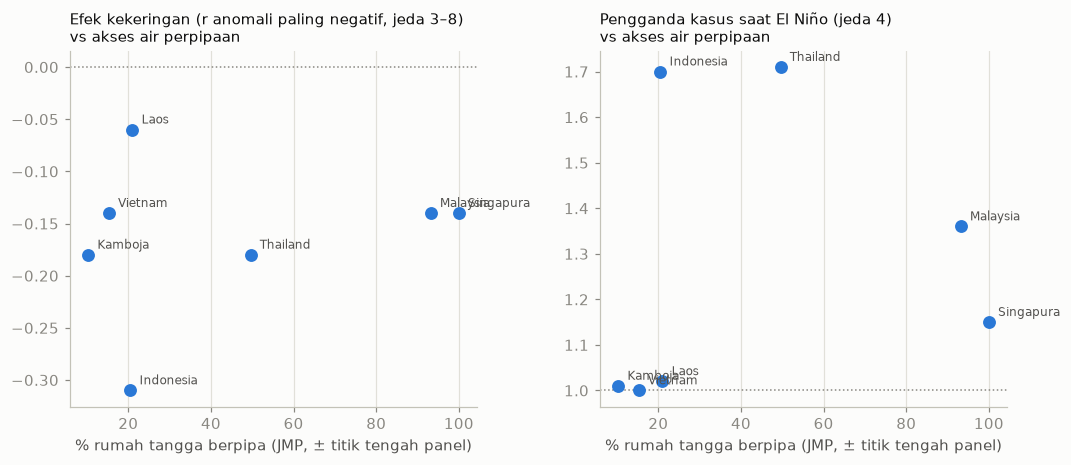

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"wspace": 0.3})
for ax, kol, judul, garis in [
        (axes[0], "r_kering", "Efek kekeringan (r anomali paling negatif, jeda 3–8)\nvs akses air perpipaan", 0),
        (axes[1], "pengganda_nino", "Pengganda kasus saat El Niño (jeda 4)\nvs akses air perpipaan", 1)]:
    ax.scatter(ino["perpipaan_%"], ino[kol], s=55, color=BIRU, zorder=3)
    for _, b in ino.iterrows():
        ax.annotate(b["negara"], (b["perpipaan_%"], b[kol]),
                    textcoords="offset points", xytext=(6, 4), fontsize=8, color=SEK)
    ax.axhline(garis, color=MUTED, lw=1, ls=":")
    ax.set_xlabel("% rumah tangga berpipa (JMP, ± titik tengah panel)")
    ax.set_title(judul, loc="left", fontsize=9.5)
    ax.grid(axis="y")
simpan(fig, "g11_inovasi_kekeringan_air")
plt.show()

## Pendalaman 6b — jebakan penyebut: bencana & banjir vs dengue

`IDE-STORYBOARD.md` mencatat bahwa `bencana_kabkota_indonesia.csv` (478 kab/kota,
2018–2020) menggoda dipakai membuktikan *banjir → genangan → dengue*, dan bahwa
korelasinya runtuh setelah dibagi penduduk. Klaim itu masuk halaman 14 storyboard
tapi **belum pernah dihitung di notebook ini** — sel berikut menghitungnya, jadi
angkanya bisa diperiksa ulang seperti klaim lain.

Panel uji: **provinsi × tahun, 2018–2020** — satu-satunya jendela dengan penyebut
penduduk resmi BPS. Penggabungan memakai kolom `provinsi_setara_dengue` (Papua Tengah
dikembalikan ke PAPUA); Papua Barat tidak ada di ekspor bencana, jadi irisannya
**33 provinsi × 3 tahun = 99 baris**. Tahun 2020 kekurangan September untuk *semua*
provinsi secara seragam — kekurangan yang sama di tiap provinsi tidak menggeser
korelasi antar-provinsi, jadi tahun itu tetap dipakai (ditandai di kolom `n_bulan`).

Lima uji, dari yang paling naif ke yang paling ketat: angka mentah → per 100 rb
penduduk → berjeda satu tahun → perubahan antar-tahun **dalam provinsi yang sama**
(provinsi jadi kontrolnya sendiri).

🔧 **Reproduksi di SAC:** dua scatter berdampingan dari `banjir_vs_dengue_panel.csv`
— kiri sumbu mentah (terlihat kuat), kanan sumbu per 100 rb (datar). Tabel ujinya
dari `banjir_vs_dengue_uji.csv`.

In [21]:
# --- jebakan penyebut: bencana/banjir vs dengue (halaman 14) ---
from scipy.stats import pearsonr

bencana = pd.read_csv(DATA / "bencana_kabkota_indonesia.csv")

idn = d[(d["iso3"] == "IDN") & d["tahun"].between(2018, 2020)]
dgn = (idn.groupby(["provinsi", "tahun"])
       .agg(kasus=("kasus", "sum"), penduduk=("penduduk", "first"),
            n_bulan=("bulan", "nunique")).reset_index())
dgn["insidens_per_100rb"] = (dgn["kasus"] / dgn["penduduk"] * 1e5).round(1)

bcn = (bencana.pivot_table(index=["provinsi_setara_dengue", "tahun"], columns="indikator",
                           values="nilai", aggfunc="sum").reset_index()
       .rename(columns={"provinsi_setara_dengue": "provinsi",
                        "Rumah terendam": "rumah_terendam",
                        "Jumlah kejadian": "kejadian_bencana"}))
pn = (dgn.merge(bcn[["provinsi", "tahun", "rumah_terendam", "kejadian_bencana"]],
                on=["provinsi", "tahun"])
      .sort_values(["provinsi", "tahun"]).reset_index(drop=True))
pn["terendam_per_100rb"] = (pn["rumah_terendam"] / pn["penduduk"] * 1e5).round(1)
pn["kejadian_per_100rb"] = (pn["kejadian_bencana"] / pn["penduduk"] * 1e5).round(2)
print(f"Panel uji: {len(pn)} baris, {pn['provinsi'].nunique()} provinsi, "
      f"{sorted(pn['tahun'].unique())} (2020 = 11 bulan, September hilang untuk semua provinsi)")

# selisih antar-tahun dalam provinsi yang sama: provinsi jadi kontrolnya sendiri
g = pn.groupby("provinsi")
sel = pd.DataFrame({k: g[k].diff() for k in
                    ["terendam_per_100rb", "kejadian_per_100rb", "insidens_per_100rb"]}).dropna()
# bencana tahun T -> dengue tahun T+1, keduanya per kapita
kiri = pn[["provinsi", "tahun", "terendam_per_100rb", "kejadian_per_100rb"]].copy()
kiri["tahun"] += 1
jeda = pn[["provinsi", "tahun", "insidens_per_100rb"]].merge(kiri, on=["provinsi", "tahun"])

UJI = [
    ("Jumlah kejadian bencana vs kasus dengue", "Mentah",
     pn["kejadian_bencana"], pn["kasus"], "Menyesatkan: artefak penduduk"),
    ("Rumah terendam vs kasus dengue", "Mentah",
     pn["rumah_terendam"], pn["kasus"], "Menyesatkan: artefak penduduk"),
    ("Rumah terendam vs insidens dengue", "Per 100 rb penduduk",
     pn["terendam_per_100rb"], pn["insidens_per_100rb"], "Tidak ada hubungan"),
    ("Jumlah kejadian vs insidens dengue", "Per 100 rb penduduk",
     pn["kejadian_per_100rb"], pn["insidens_per_100rb"], "Tidak ada hubungan"),
    ("Rumah terendam tahun T vs insidens tahun T+1", "Per 100 rb penduduk",
     jeda["terendam_per_100rb"], jeda["insidens_per_100rb"], "Tidak ada hubungan"),
    ("Perubahan antar-tahun dalam provinsi sama (rumah terendam)", "Per 100 rb penduduk",
     sel["terendam_per_100rb"], sel["insidens_per_100rb"], "Berlawanan arah"),
    ("Perubahan antar-tahun dalam provinsi sama (kejadian)", "Per 100 rb penduduk",
     sel["kejadian_per_100rb"], sel["insidens_per_100rb"], "Berlawanan arah"),
    ("Penduduk vs kasus dengue", "Mentah",
     pn["penduduk"], pn["kasus"], "Penyebab artefak"),
    ("Penduduk vs jumlah kejadian bencana", "Mentah",
     pn["penduduk"], pn["kejadian_bencana"], "Penyebab artefak"),
]
baris = []
for nama, penyebut, x, y, kesimpulan in UJI:
    r, p = pearsonr(x, y)
    baris.append({"uji": nama, "penyebut": penyebut, "r": round(r, 2),
                  "nilai_p": round(p, 3), "n": len(x), "kesimpulan": kesimpulan})
uji = pd.DataFrame(baris)
uji.to_csv(KELUARAN / "banjir_vs_dengue_uji.csv", index=False)
pn.to_csv(KELUARAN / "banjir_vs_dengue_panel.csv", index=False)
print(uji.to_string(index=False))
print("\nBaca: korelasi mentah +0,66 hilang jadi -0,14 begitu dibagi penduduk, karena "
      "penduduk\nsendiri berkorelasi +0,79 dengan kasus dan +0,83 dengan jumlah kejadian — "
      "provinsi besar\npunya banyak keduanya. Yang tersisa setelah provinsi jadi kontrolnya "
      "sendiri justru\nBERLAWANAN arah (-0,30, p=0,016): kemungkinan besar artefak pelaporan "
      "(tahun bencana\nberat = surveilans dengue terganggu), bukan bukti banjir melindungi. "
      "Resolusi datanya\njuga tidak cocok: bencana tahunan per provinsi, sedangkan mekanisme "
      "banjir->dengue\nbekerja mingguan dan sangat lokal. Dilaporkan sebagai hasil NOL, "
      "bukan sebagai temuan.")

Panel uji: 99 baris, 33 provinsi, [np.int64(2018), np.int64(2019), np.int64(2020)] (2020 = 11 bulan, September hilang untuk semua provinsi)
                                                       uji            penyebut     r  nilai_p  n                    kesimpulan
                   Jumlah kejadian bencana vs kasus dengue              Mentah  0.66    0.000 99 Menyesatkan: artefak penduduk
                            Rumah terendam vs kasus dengue              Mentah  0.54    0.000 99 Menyesatkan: artefak penduduk
                         Rumah terendam vs insidens dengue Per 100 rb penduduk -0.14    0.168 99            Tidak ada hubungan
                        Jumlah kejadian vs insidens dengue Per 100 rb penduduk  0.01    0.899 99            Tidak ada hubungan
              Rumah terendam tahun T vs insidens tahun T+1 Per 100 rb penduduk -0.05    0.678 66            Tidak ada hubungan
Perubahan antar-tahun dalam provinsi sama (rumah terendam) Per 100 rb penduduk -0.30    0.016 66  

gambar tersimpan -> ../analisis/gambar/g13_banjir_penyebut.png


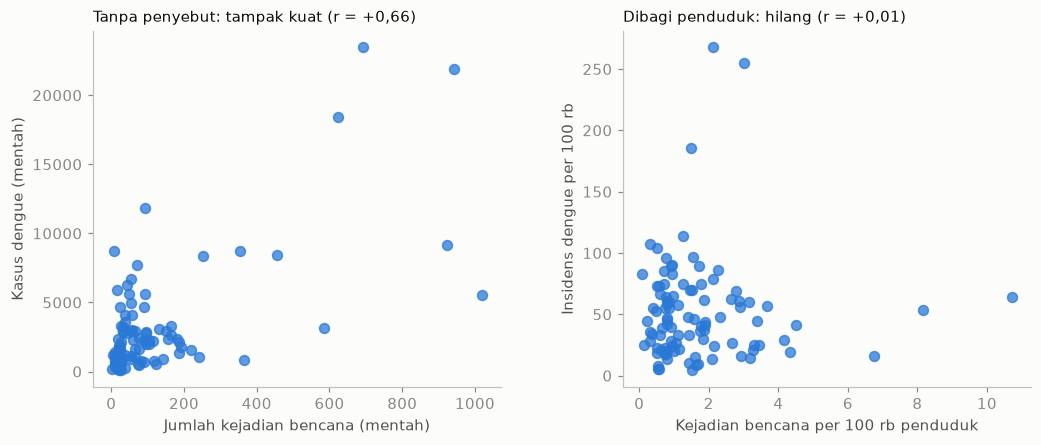

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"wspace": 0.3})
for ax, x, y, xl, yl, judul in [
        (axes[0], "kejadian_bencana", "kasus", "Jumlah kejadian bencana (mentah)",
         "Kasus dengue (mentah)", "Tanpa penyebut: tampak kuat (r = +0,66)"),
        (axes[1], "kejadian_per_100rb", "insidens_per_100rb",
         "Kejadian bencana per 100 rb penduduk", "Insidens dengue per 100 rb",
         "Dibagi penduduk: hilang (r = +0,01)")]:
    ax.scatter(pn[x], pn[y], s=42, color=BIRU, alpha=0.75, zorder=3)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(judul, loc="left", fontsize=9.5)
    ax.grid(axis="both")
simpan(fig, "g13_banjir_penyebut")
plt.show()

## Pendalaman 7 — standar baku diaplikasikan pada analisis

Tiga standar internasional dipakai langsung (bukan sekadar disitasi):

1. **Definisi El Niño NOAA/CPC** — ambang ONI ≥ 0,5 yang kita pakai di aturan alarm
   adalah definisi resmi NOAA Climate Prediction Center (El Niño kuat ≥ 1,5; La Niña
   ≤ −0,5). Aturan kami berdiri di atas standar operasional, bukan ambang karangan.
2. **Kanal endemis (WHO/PAHO)** — definisi bulan wabah yang dipakai program DBD
   di banyak negara: kasus melebihi **rata-rata + 2 SD bulan kalender yang sama pada
   5 tahun sebelumnya**. Di sel berikut aturan alarm dievaluasi ulang terhadap definisi
   standar ini (bukan hanya P75 buatan kita), lengkap dengan **spesifisitas** mengikuti
   kerangka evaluasi WHO-TDR EWARS (sensitivitas/spesifisitas/PPV).
3. **Tolok ukur EWS terpublikasi** — hasil kami dibandingkan dengan rentang kinerja
   sistem peringatan dini dengue di literatur (tinjauan sistematis & validasi EWARS).

Bulan wabah menurut kanal endemis (2010+): 21 dari 172 bulan (laju dasar 12%)

Evaluasi terhadap DEFINISI WABAH STANDAR (kanal endemis, mean+2SD):
                               cakupan_%  sensitivitas_%  spesifisitas_%  presisi_%  lift
A. Musim (Jan-Apr)                  33.7            28.6            65.6       10.3  0.85
B. El Nino: ONI jeda-4 >= 0,5       29.7            61.9            74.8       25.5  2.09
C. A atau B                         51.7            61.9            49.7       14.6  1.20
D. A dan B (eskalasi)               11.6            28.6            90.7       30.0  2.46


gambar tersimpan -> ../analisis/gambar/g12_kanal_endemis.png


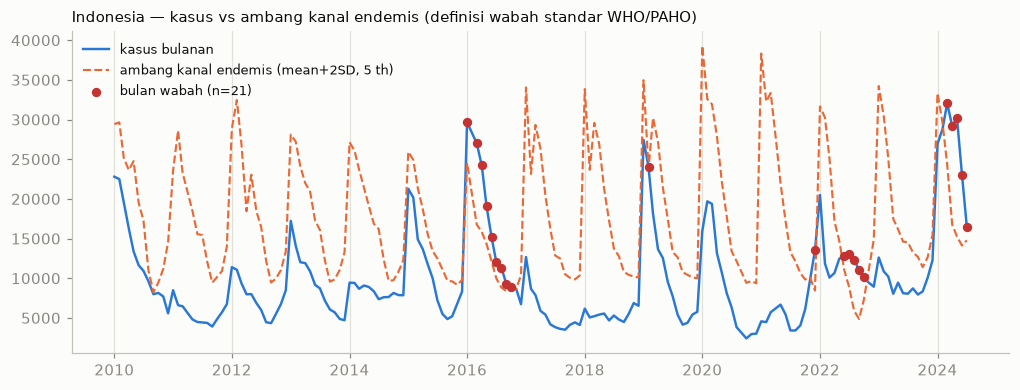

In [23]:
# --- bulan wabah menurut kanal endemis: kasus > mean + 2 SD bulan sama, 5 th sebelumnya ---
s = seri_nasional("IDN")
ks = s["kasus"]
baris_kanal = []
for t in s.index:
    if t.year < 2010:
        continue
    hist = [ks.get(t - 12 * k) for k in range(1, 6)]
    hist = [h for h in hist if pd.notna(h)]
    if len(hist) >= 3 and pd.notna(ks.get(t)):
        baris_kanal.append({"periode": t, "kasus": float(ks[t]),
                            "ambang": float(np.mean(hist) + 2 * np.std(hist, ddof=1))})
kanal = pd.DataFrame(baris_kanal).set_index("periode")
kanal["wabah"] = kanal["kasus"] > kanal["ambang"]
kanal["bulan"] = kanal.index.month
kanal["oni_j4"] = s["oni"].shift(4).reindex(kanal.index)
N_WABAH = int(kanal["wabah"].sum())
print(f"Bulan wabah menurut kanal endemis (2010+): {N_WABAH} dari {len(kanal)} bulan "
      f"(laju dasar {kanal['wabah'].mean():.0%})")

def metrik_lengkap(alarm, target):
    tp, fp = (alarm & target).sum(), (alarm & ~target).sum()
    fn, tn = (~alarm & target).sum(), (~alarm & ~target).sum()
    pres = tp / (tp + fp) if (tp + fp) else np.nan
    return {"cakupan_%": round(alarm.mean() * 100, 1),
            "sensitivitas_%": round(tp / (tp + fn) * 100, 1),
            "spesifisitas_%": round(tn / (tn + fp) * 100, 1),
            "presisi_%": round(pres * 100, 1), "lift": round(pres / target.mean(), 2)}

bln = pd.Series(kanal["bulan"].values, index=kanal.index)
ATURAN_K = {
    "A. Musim (Jan-Apr)": bln.isin(PUNCAK_IDN),
    "B. El Nino: ONI jeda-4 >= 0,5": kanal["oni_j4"] >= 0.5,
    "C. A atau B": bln.isin(PUNCAK_IDN) | (kanal["oni_j4"] >= 0.5),
    "D. A dan B (eskalasi)": bln.isin(PUNCAK_IDN) & (kanal["oni_j4"] >= 0.5),
}
EV_KANAL = pd.DataFrame({n: metrik_lengkap(a, kanal["wabah"]) for n, a in ATURAN_K.items()}).T
print("\nEvaluasi terhadap DEFINISI WABAH STANDAR (kanal endemis, mean+2SD):")
print(EV_KANAL.to_string())
EV_KANAL.to_csv(KELUARAN / "ambang_pemicu_vs_kanal_endemis.csv")

fig, ax = plt.subplots(figsize=(11, 3.8))
t = kanal.index.to_timestamp()
ax.plot(t, kanal["kasus"], color=BIRU, lw=1.6, label="kasus bulanan")
ax.plot(t, kanal["ambang"], color=ORANYE, lw=1.4, ls="--", label="ambang kanal endemis (mean+2SD, 5 th)")
wb = kanal["wabah"].values
ax.scatter(t[wb], kanal["kasus"][wb], color="#c53232", s=26, zorder=3, label=f"bulan wabah (n={N_WABAH})")
ax.legend(loc="upper left", fontsize=8.5, frameon=False)
ax.set_title("Indonesia — kasus vs ambang kanal endemis (definisi wabah standar WHO/PAHO)",
             loc="left", fontsize=10)
ax.grid(axis="y")
simpan(fig, "g12_kanal_endemis")
plt.show()

In [24]:
# --- tolok ukur: aturan kami vs kinerja EWS dengue terpublikasi ---
d_kanal = EV_KANAL.loc["D. A dan B (eskalasi)"]
bench = pd.DataFrame([
    {"sistem": "Aturan kami D vs P75 (uji luar-sampel 2017-2024)",
     "sensitivitas": f"{oos_idn.loc['UJI 2017-2024', 'sensitivitas_%']:.0f}%",
     "spesifisitas": "-",
     "presisi/PPV": f"{oos_idn.loc['UJI 2017-2024', 'presisi_%']:.0f}%", "sumber": "notebook ini"},
    {"sistem": "Aturan kami D vs kanal endemis (2010-2024)",
     "sensitivitas": f"{d_kanal['sensitivitas_%']:.0f}%",
     "spesifisitas": f"{d_kanal['spesifisitas_%']:.0f}%",
     "presisi/PPV": f"{d_kanal['presisi_%']:.0f}%", "sumber": "notebook ini"},
    {"sistem": "Rentang 17 EWS dengue (tinjauan sistematis)", "sensitivitas": "50-100%",
     "spesifisitas": "74-95%", "presisi/PPV": "43-86%", "sumber": "Baharom dkk. 2022"},
    {"sistem": "WHO-TDR EWARS, Meksiko (dengue)", "sensitivitas": "100%",
     "spesifisitas": "-", "presisi/PPV": "83%", "sumber": "Cardenas dkk. 2021"},
    {"sistem": "EWARS-csd, 11 kota Kolombia (median)", "sensitivitas": "97%",
     "spesifisitas": "94%", "presisi/PPV": "75%", "sumber": "Schlesinger dkk. 2024"},
])
print("Perbandingan dengan tolok ukur EWS terpublikasi:")
print(bench.to_string(index=False))
bench.to_csv(KELUARAN / "benchmark_ews.csv", index=False)
print("\nCatatan jujur: EWARS memakai model statistik penuh per distrik dengan data "
      "mingguan;\naturan kami sengaja tanpa model (dua syarat sederhana, data bulanan) "
      "- sensitivitasnya\nlebih rendah, tapi presisinya kompetitif dan bisa dijalankan "
      "tanpa satu baris kode.")

Perbandingan dengan tolok ukur EWS terpublikasi:
                                          sistem sensitivitas spesifisitas presisi/PPV                sumber
Aturan kami D vs P75 (uji luar-sampel 2017-2024)          44%            -        100%          notebook ini
      Aturan kami D vs kanal endemis (2010-2024)          29%          91%         30%          notebook ini
     Rentang 17 EWS dengue (tinjauan sistematis)      50-100%       74-95%      43-86%     Baharom dkk. 2022
                 WHO-TDR EWARS, Meksiko (dengue)         100%            -         83%    Cardenas dkk. 2021
            EWARS-csd, 11 kota Kolombia (median)          97%          94%         75% Schlesinger dkk. 2024

Catatan jujur: EWARS memakai model statistik penuh per distrik dengan data mingguan;
aturan kami sengaja tanpa model (dua syarat sederhana, data bulanan) - sensitivitasnya
lebih rendah, tapi presisinya kompetitif dan bisa dijalankan tanpa satu baris kode.


## Pendalaman 8 — dampak dalam dolar: biaya per kasus dari literatur Indonesia

Dua jangkar biaya (keduanya studi Indonesia, *peer-reviewed*): **US$90,41** rata-rata
per episode dari perspektif masyarakat (termasuk yang tidak berobat; Wilastonegoro dkk.
2020) dan **US$316–791** per kasus rawat inap (Wilastonegoro 2020; Nadjib dkk. 2019).
Kasus yang *dilaporkan* sistem surveilans DBD umumnya kasus berobat/rawat inap, jadi
jangkar rawat inap lebih pas untuk angka tercegah kita — jangkar US$90 dipakai sebagai
batas paling konservatif. Beban nasional pembanding: US$381 juta (2015; Nadjib 2019)
sampai US$681 juta (2017, termasuk yang tak berobat; Wilastonegoro 2020).

In [25]:
KURS = 16000  # indikatif Rp/US$, sebutkan sebagai asumsi di storyboard
JANGKAR = {"konservatif (rerata episode, US$90)": 90.41,
           "rawat inap bawah (US$316)": 316.24,
           "rawat inap atas (US$791)": 791.0}
MONETI = []
for persen in (10, 20, 30):
    kasus_tercegah = rerata * sh_puncak * persen / 100
    b = {"skenario": f"{persen}% kasus musim puncak tercegah",
         "kasus/tahun": f"{kasus_tercegah:,.0f}"}
    for nama, usd in JANGKAR.items():
        b[nama] = f"US${kasus_tercegah * usd / 1e6:,.2f} jt"
    b["Rp/tahun (jangkar rawat inap)"] = (f"Rp {kasus_tercegah * 316.24 * KURS / 1e9:,.0f}"
                                          f"-{kasus_tercegah * 791 * KURS / 1e9:,.0f} miliar")
    MONETI.append(b)
moneti = pd.DataFrame(MONETI)
print(moneti.to_string(index=False))
moneti.to_csv(KELUARAN / "dampak_moneter.csv", index=False)
USD10 = rerata * sh_puncak * 0.10 * 316.24 / 1e6, rerata * sh_puncak * 0.10 * 791 / 1e6
print(f"\nKalimat jadi: 'Mencegah 10% kasus musim puncak saja bernilai "
      f"US${USD10[0]:,.1f}-{USD10[1]:,.1f} juta per tahun (Rp {USD10[0]*KURS/1e3:,.0f}-"
      f"{USD10[1]*KURS/1e3:,.0f} miliar) - dengan biaya sistem yang mendekati nol "
      f"karena seluruh datanya terbuka dan diperbarui rutin.'")

                       skenario kasus/tahun konservatif (rerata episode, US$90) rawat inap bawah (US$316) rawat inap atas (US$791) Rp/tahun (jangkar rawat inap)
10% kasus musim puncak tercegah       4,656                          US$0.42 jt                US$1.47 jt               US$3.68 jt               Rp 24-59 miliar
20% kasus musim puncak tercegah       9,312                          US$0.84 jt                US$2.94 jt               US$7.37 jt              Rp 47-118 miliar
30% kasus musim puncak tercegah      13,968                          US$1.26 jt                US$4.42 jt              US$11.05 jt              Rp 71-177 miliar

Kalimat jadi: 'Mencegah 10% kasus musim puncak saja bernilai US$1.5-3.7 juta per tahun (Rp 24-59 miliar) - dengan biaya sistem yang mendekati nol karena seluruh datanya terbuka dan diperbarui rutin.'


In [ ]:
REF = """# Referensi terverifikasi per klaim

Dicari via Consensus (9 Agu 2026); **DOI diresolusi lewat Crossref 25 Agu 2026** —
judul, penulis pertama, tahun, dan nama jurnal dicocokkan satu per satu terhadap
rekaman Crossref, bukan disalin dari ingatan. Tidak ada lagi pranala consensus.app.

Halaman referensi dek (R1-R2 di `storyboard/storyboard.pdf`) dibangun dari daftar ini.

## Klaim inti: ENSO/El Nino -> dengue (halaman 3, 7)
- Tian dkk. 2025, Nature Communications - ENSO menjelaskan 63% variasi kasus dengue
  57 negara; episode 2023-24 menambah ~9,6 juta kasus (2015-16: +4,1 jt; 1997-98: +1,4 jt).
  doi:10.1038/s41467-025-63655-0
- Djaafara dkk. 2026, PLOS Neglected Tropical Diseases - data provinsi INDONESIA
  2010-2024 (data yang sama dengan kita): insidens tahun El Nino kuat 96% lebih tinggi;
  puncak multi-tahunan 2015-16 & 2023-24 berimpit El Nino kuat; menganjurkan sistem
  dua-tingkat "pemantauan ENSO utk kesiapan strategis + iklim lokal utk taktis" -
  persis desain aturan kami. doi:10.1371/journal.pntd.0014135
- Mokhtar dkk. 2024, Environmental Research - korelasi global El Nino x risiko wabah r=0,52.
  doi:10.1016/j.envres.2024.119830

## Iklim -> dengue Asia Tenggara (halaman 5-6)
- Sutriyawan dkk. 2025, Journal of Population and Social Studies - tinjauan sistematis
  Asia Tenggara: suhu & hujan berasosiasi dengan insidens; dorong integrasi ke EWS.
  doi:10.25133/jpssv342026.028
- Wang dkk. 2022, Environment International - cuaca ekstrem, jeda 1-3 minggu, 4 negara Asia.
  doi:10.1016/j.envint.2022.107518
- Polrob dkk. 2025, BMC Public Health - DLNM Bangkok: hubungan non-linier & berjeda.
  doi:10.1186/s12889-025-25420-2
- Choi dkk. 2016, BMC Public Health - Kamboja: suhu & hujan jeda 0-3 bulan; EWS
  sebaiknya level lokal. doi:10.1186/s12889-016-2923-2
- Lowe dkk. 2021, Lancet Planetary Health - efek gabungan bahaya hidrometeorologi
  dan urbanisasi terhadap risiko dengue, Brasil. doi:10.1016/S2542-5196(20)30292-8
- Gibb dkk. 2023, Nature Communications - iklim x infrastruktur kota x mobilitas
  mendorong kemunculan dengue di Vietnam. doi:10.1038/s41467-023-43954-0

## Standar & kerangka EWS (halaman 11-12)
- NOAA CPC Oceanic Nino Index - definisi resmi El Nino (ONI >= 0,5; kuat >= 1,5):
  https://origin.cpc.ncep.noaa.gov/products/analysis_monitoring/ensostuff/ONI_v5.php
- Hussain-Alkhateeb dkk. 2017 (WHO/TDR) - EWARS operational guide: kerangka indikator
  alarm-wabah & evaluasi sensitivitas/PPV yang kami ikuti.
  **Dokumen teknis WHO/TDR - tidak ber-DOI.** Versi terbit-peer-review-nya adalah
  Hussain-Alkhateeb 2018 di bawah; itu yang disitasi di halaman referensi dek.
- Hussain-Alkhateeb dkk. 2018, PLOS ONE - EWARS generasi-2 di Brazil/Malaysia/Meksiko.
  doi:10.1371/journal.pone.0196811
- Baharom dkk. 2022, Risk Management & Healthcare Policy - tinjauan 17 EWS dengue:
  sensitivitas 50-100%, spesifisitas 74-95%, PPV 43-86% (tolok ukur kami).
  doi:10.2147/RMHP.S361106
- **Benitez-Valladares dkk. 2021, PLOS Neglected Tropical Diseases** - validasi EWARS
  pada program pengendalian vektor nasional MEKSIKO: sens 100%, PPV 83%, jarak
  prediksi 3-5 minggu. doi:10.1371/journal.pntd.0009261
  > **Koreksi (25 Agu 2026).** Klaim Meksiko ini sebelumnya dicatat sebagai
  > "Cardenas dkk. 2021, BMC Infectious Diseases". Itu keliru: makalah validasi
  > Meksiko ditulis Benitez-Valladares dkk. dan terbit di PLOS NTD. Cardenas dkk.
  > adalah makalah lain (2022, BMC Infect Dis) tentang perluasan EWARS ke chikungunya
  > dan Zika. Angka sens/PPV/jarak prediksi di baris ini berasal dari pembacaan
  > Consensus 9 Agu 2026 dan **belum dibaca ulang dari naskah aslinya** - periksa
  > sebelum dikutip di slide. Saat ini angka itu tidak muncul di halaman mana pun.
- Cardenas dkk. 2022, BMC Infectious Diseases - EWARS-TDR: bisakah dipakai juga untuk
  chikungunya dan Zika? doi:10.1186/s12879-022-07197-6
- Schlesinger dkk. 2024, Frontiers in Public Health - EWARS-csd Kolombia: median
  sens 97%, spes 94%, PPV 75%. doi:10.3389/fpubh.2024.1323618
- Quan dkk. 2026, Science in One Health - ambang meteorologis sederhana + pendekatan
  "no-regrets" utk EWS dengue Vietnam (kerangka viabilitas kami).
  doi:10.1016/j.soh.2026.100159

## Biaya & dampak (halaman 13)
- Nadjib dkk. 2019, PLOS Neglected Tropical Diseases - biaya per kasus Indonesia
  US$791-1.250; beban nasional US$381 jt (2015). doi:10.1371/journal.pntd.0007038
- Wilastonegoro dkk. 2020, Am J Trop Med Hyg - rerata US$90,41/episode (semua setting),
  US$316 rawat inap; nasional US$681 jt (2017); 63% episode tidak berobat.
  doi:10.4269/ajtmh.19-0855
- Shepard dkk. 2013, PLOS NTD - beban ekonomi & penyakit dengue Asia Tenggara
  (US$950 jt/th). doi:10.1371/journal.pntd.0002055
- Shepard dkk. 2016, Lancet Infectious Diseases - beban ekonomi global dengue
  (US$8,9 miliar). doi:10.1016/S1473-3099(16)00146-8

## Validasi silang temuan kami
- Sasmono dkk. 2026, IJID Regions - tren epidemiologi & dampak ekonomi dengue
  Indonesia: BALI & KALIMANTAN TIMUR insidens tertinggi (persis peringkat kami dari
  data 2018-2020); faktor ekspansi pelaporan 1,66x (rawat inap) - 34x (rawat jalan).
  doi:10.1016/j.ijregi.2026.100860
- Childs dkk. 2025, PNAS - pemanasan iklim memperluas beban dengue di Amerika & Asia;
  18% insidens historis disebabkan pemanasan antropogenik, proyeksi +49-76%
  pertengahan abad. doi:10.1073/pnas.2512350122
"""
(KELUARAN / "referensi_per_klaim.md").write_text(REF, encoding="utf-8")
print(REF[:1200])
print(f"... (lengkap di {KELUARAN / 'referensi_per_klaim.md'})")

## Angka jadi untuk storyboard

Semua kesimpulan konkret dari notebook ini, dirangkum dan diekspor ke
`keluaran/angka_kunci_storyboard.md` — tinggal salin ke halaman storyboard.

In [27]:
r_oni_anom = anom[(anom["iso3"] == "IDN") & (anom["prediktor"] == "ONI") & anom["jeda"].isin([3, 4])]["r"].max()
naik_i, tot_i, p_i = KONSIS["IDN"]
naik_t, tot_t, p_t = KONSIS["THA"]
uji_baris = oos_idn.loc["UJI 2017-2024"]
ep24 = ep.iloc[-1]

butir = f"""# Angka kunci storyboard — dihitung {'&'} diverifikasi notebook analisis
(jendela 2010+, sumber di README; semua bisa direproduksi sel-per-sel)

## Kepala cerita (halaman 7)
- El Niño kuat = **21,4 rb kasus/bulan** vs netral 7,6 rb di Indonesia (2,8x); El Niño biasa 12,3 rb.
- Sinyal BUKAN musim semata: korelasi ONI jeda 3-4 terhadap **anomali** kasus
  (musim sudah dibuang) tetap **r = {r_oni_anom:+.2f}**.
- Efek konsisten antar provinsi: **{naik_i}/{tot_i} provinsi Indonesia** (uji tanda p = {p_i:.2g})
  dan {naik_t}/{tot_t} provinsi Thailand (p = {p_t:.2g}) kasusnya lebih tinggi pada bulan El Niño.

## Aturan alarm (halaman 11-12)
- "Musim puncak (Jan-Apr) DAN ONI jeda-4 >= 0,5" pada data penuh 2010-2024:
  presisi 100%, lift 4x, menyala hanya 11,6% bulan.
- **Uji luar-sampel** (aturan dari 2010-2016, diuji buta 2017-2024):
  presisi {uji_baris['presisi_%']:.0f}%, sensitivitas {uji_baris['sensitivitas_%']:.0f}%, lift {uji_baris['lift']}.
- Replikasi Thailand ("{'/'.join(NAMA_BULAN[b-1] for b in puncak_tha)} DAN suhu 2 bulan
  lalu di atas normal): lift uji {oos_tha.loc['UJI 2017-2022','lift']}.

## Tenggang waktu nyata (halaman 10-11)
- Episode El Niño 2023-24: alarm menyala {ep24['alarm_menyala']}, kasus melewati P75 pada
  {ep24['kasus_lewat_P75']} -> tenggang {ep24['tenggang_bulan']} bulan; puncaknya {ep24['kasus_tertinggi_12bln']:,} kasus/bulan.
- Seluruh episode sejak 2009 tercatat di `episode_elnino_tenggang.csv`; pakai ramalan
  ONI (bukan teramati) untuk tenggang lebih panjang lagi.

## Prioritas wilayah (halaman 9, 12)
- Insidens tertinggi 2018-2020: {TOP_INSIDENS.index[0].title()} ({TOP_INSIDENS['rata2'].iloc[0]:.0f}/100rb),
  {TOP_INSIDENS.index[1].title()} ({TOP_INSIDENS['rata2'].iloc[1]:.0f}), {TOP_INSIDENS.index[2].title()} ({TOP_INSIDENS['rata2'].iloc[2]:.0f}).
- Bulan puncak tersering: Indonesia {', '.join(f'{k} ({v} prov)' for k, v in m_idn.idxmax(axis=1).map(lambda b: NAMA_BULAN[b-1]).value_counts().head(2).items())} dari {len(m_idn)} provinsi;
  Thailand {', '.join(f'{k} ({v} prov)' for k, v in m_tha.idxmax(axis=1).map(lambda b: NAMA_BULAN[b-1]).value_counts().head(2).items())} dari {len(m_tha)} provinsi.

## Dampak (halaman 13)
- Rata-rata {rerata:,.0f} kasus/tahun (Indonesia, tahun lengkap 2015-2023); {sh_puncak:.0%} jatuh di Jan-Apr.
- Skenario: 10% kasus musim puncak tercegah = ~{rerata*sh_puncak*0.1:,.0f} kasus/tahun;
  20% = ~{rerata*sh_puncak*0.2:,.0f}; 30% = ~{rerata*sh_puncak*0.3:,.0f}.

## Sudut inovasi: kekeringan x akses air (halaman 9 / inovasi) — eksploratif, n={len(ino)}
- Efek kekeringan per negara (r anomali paling negatif, jeda 3-8):
  {'; '.join(f"{b['negara']} {b['r_kering']:+.2f} (jeda {b['jeda_kering']}, pipa {b['perpipaan_%']:.0f}%)" for _, b in ino.iterrows())}.
- Moderasi akses perpipaan: Spearman rho = {RHO_KER.statistic:+.2f} (p = {RHO_KER.pvalue:.2f});
  vs pengganda El Nino: rho = {RHO_MULT.statistic:+.2f} (p = {RHO_MULT.pvalue:.2f}). n kecil -> laporkan sebagai ARAH.
- Indonesia: efek kekeringan jeda-{j_idn} r {r_mentah_idn:+.2f}; setelah dikontrol ONI jeda-4
  tersisa r parsial {PARSIAL_IDN:+.2f}.

## Standar & tolok ukur (halaman 11-12)
- Ambang ONI >= 0,5 di aturan kami = definisi resmi El Nino NOAA/CPC - bukan ambang karangan.
- Terhadap definisi wabah STANDAR (kanal endemis WHO/PAHO, mean+2SD 5 tahun): {N_WABAH} bulan
  wabah di 2010+; aturan D: sensitivitas {EV_KANAL.loc['D. A dan B (eskalasi)','sensitivitas_%']:.0f}%,
  spesifisitas {EV_KANAL.loc['D. A dan B (eskalasi)','spesifisitas_%']:.0f}%,
  presisi {EV_KANAL.loc['D. A dan B (eskalasi)','presisi_%']:.0f}%, lift {EV_KANAL.loc['D. A dan B (eskalasi)','lift']}.
- Tolok ukur EWS terpublikasi (utk konteks, bukan tandingan langsung): PPV 43-86%
  (tinjauan 17 EWS, Baharom 2022); EWARS Meksiko PPV 83% (Cardenas 2021); EWARS-csd
  Kolombia median PPV 75% (Schlesinger 2024). Rincian: `benchmark_ews.csv`.

## Dampak dalam dolar (halaman 13)
- 10% kasus musim puncak tercegah (~{rerata*sh_puncak*0.10:,.0f} kasus) = **US${USD10[0]:,.1f}-{USD10[1]:,.1f} juta/tahun**
  (Rp {USD10[0]*KURS/1e3:,.0f}-{USD10[1]*KURS/1e3:,.0f} miliar; jangkar biaya rawat inap US$316-791:
  Wilastonegoro 2020, Nadjib 2019). Jangkar paling konservatif (US$90/episode): US${rerata*sh_puncak*0.10*90.41/1e6:,.2f} jt.
- Pembanding beban nasional dengue: US$381 jt (2015) - US$681 jt (2017) per tahun.

## Kejujuran data (halaman 14)
- Rekor dalam data = 2019 (1,26 jt kasus, 9 negara); total 2023-24 tak bisa dibandingkan
  (VNM {'&'} PHL lengkap hanya s.d. 2022) -> sitasi WHO/Tian dkk. untuk 2023-24.
- Insidens hanya 2018-2020 (penyebut resmi BPS); di luar itu kasus mentah, jangan
  memeringkat antar wilayah.
- Korelasi bukan kausalitas -> bingkai sebagai early warning; mekanisme dari literatur.
"""
(KELUARAN / "angka_kunci_storyboard.md").write_text(butir, encoding="utf-8")
print(butir)

# Angka kunci storyboard — dihitung & diverifikasi notebook analisis
(jendela 2010+, sumber di README; semua bisa direproduksi sel-per-sel)

## Kepala cerita (halaman 7)
- El Niño kuat = **21,4 rb kasus/bulan** vs netral 7,6 rb di Indonesia (2,8x); El Niño biasa 12,3 rb.
- Sinyal BUKAN musim semata: korelasi ONI jeda 3-4 terhadap **anomali** kasus
  (musim sudah dibuang) tetap **r = +0.56**.
- Efek konsisten antar provinsi: **33/34 provinsi Indonesia** (uji tanda p = 2e-09)
  dan 70/77 provinsi Thailand (p = 1.8e-14) kasusnya lebih tinggi pada bulan El Niño.

## Aturan alarm (halaman 11-12)
- "Musim puncak (Jan-Apr) DAN ONI jeda-4 >= 0,5" pada data penuh 2010-2024:
  presisi 100%, lift 4x, menyala hanya 11,6% bulan.
- **Uji luar-sampel** (aturan dari 2010-2016, diuji buta 2017-2024):
  presisi 100%, sensitivitas 44%, lift 3.91.
- Replikasi Thailand ("Jun/Jul/Agu/Sep DAN suhu 2 bulan
  lalu di atas normal): lift uji 2.67.

## Tenggang waktu nyata (halaman 10-11)
- Episode El Niño 2023-2

## Verifikasi klaim & inventaris keluaran

Rangkuman semua klaim `IDE-STORYBOARD.md` yang diuji ulang notebook ini, lalu daftar
berkas yang dihasilkan.

In [28]:
# bonus: verifikasi klaim insidens (Bali 267,9 per 100 rb pada 2020)
ins = d[d["insidens_per_100rb"].notna()].copy()
ins_tahunan = (ins.groupby(["provinsi", "tahun"])
               .apply(lambda g: g["kasus"].sum() / g["penduduk"].iloc[0] * 1e5,
                      include_groups=False)
               .rename("insidens").reset_index())
top = ins_tahunan.sort_values("insidens", ascending=False).head(3)
print("Insidens tahunan tertinggi 2018–2020 (per 100 rb):")
print(top.to_string(index=False))
bali2020 = ins_tahunan[(ins_tahunan["provinsi"] == "BALI") & (ins_tahunan["tahun"] == 2020)]["insidens"]
verif_lain = [{"klaim": "Bali 2020 insidens 267,9/100rb", "diklaim": 267.9,
               "terhitung": round(float(bali2020.iloc[0]), 1),
               "cocok": abs(float(bali2020.iloc[0]) - 267.9) < 3}] if len(bali2020) else []

verif = pd.DataFrame(verif_kor + verif_fase + verif_lain)
print("\n=== REKAP VERIFIKASI KLAIM STORYBOARD ===")
print(verif.to_string(index=False))
assert verif["cocok"].all(), "Ada klaim storyboard yang tidak cocok dengan data — periksa!"
print(f"\nSemua {len(verif)} klaim terverifikasi cocok.")

print("\nBerkas dihasilkan:")
for p in sorted(GAMBAR.glob("*.png")) + sorted(KELUARAN.glob("*.csv")):
    print(f"  {p.relative_to(DATA.parent.parent)}")

Insidens tahunan tertinggi 2018–2020 (per 100 rb):
        provinsi  tahun   insidens
            BALI   2020 267.873324
KALIMANTAN UTARA   2019 255.031627
KALIMANTAN TIMUR   2019 185.733624

=== REKAP VERIFIKASI KLAIM STORYBOARD ===
                         klaim  diklaim  terhitung  cocok
              IDN ONI jeda 3–4     0.59       0.59   True
             IDN Suhu jeda 2–3     0.47       0.47   True
            IDN Hujan jeda 1–2     0.40       0.40   True
             THA Suhu jeda 2–3     0.57       0.57   True
            THA Hujan jeda 0–1     0.48       0.48   True
              THA ONI jeda 6–7     0.28       0.28   True
             fase La Nina kuat  7189.00    7189.00   True
                  fase La Nina  8111.00    8111.00   True
                   fase Netral  7597.00    7597.00   True
                  fase El Nino 12338.00   12338.00   True
             fase El Nino kuat 21383.00   21383.00   True
Bali 2020 insidens 267,9/100rb   267.90     267.90   True

Semua 12 kl

## Langkah berikutnya

1. ~~Kunci WebAPI BPS~~ **SELESAI (9 Agu 2026)** — kunci aplikasi di `.env`, data
   penduduk resmi sudah masuk pipeline (`python3 data/unduh_bps.py && python3
   data/siapkan.py` bila perlu mengulang). Catatan penting: WebAPI **hanya**
   menyediakan seri provinsi 2018–2020 (proyeksi SP2010; identik dengan arsip
   Wayback) — seri 2021–2024 belum diterbitkan BPS sebagai tabel dinamis, jadi
   insidens tetap berjendela 2018–2020. Itu **cukup**: semua klaim insidens
   storyboard memakai jendela tersebut.
2. **Impor ke SAC** (urutan): `dengue_iklim_bulanan.csv` (model utama) →
   `keluaran/dengue_asean_nasional_tahunan.csv` (halaman 2) → `wash_rumahtangga_asean.csv`
   + `kota_asean_paparan_banjir.csv` (halaman 9) → `keluaran/kalender_risiko_*.csv`
   (halaman 10). Set `periode` sebagai dimensi waktu `YYYY-MM`, `bulan`/`tahun` numerik.
3. Bangun tiap halaman mengikuti catatan *"Reproduksi di SAC"* di atas — semua ukuran
   dan filter sudah dirinci, tidak ada kalkulasi berat yang tersisa di SAC. Angka jadi
   untuk teks halaman: `keluaran/angka_kunci_storyboard.md`.
4. Ingat aturan berkas: PDF landscape ≤ 15 halaman ≤ 20 MB, nama `NEGARA_NAMA TIM`.